In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(rc={'figure.figsize':(10, 10)}, font_scale=1.3)

# 📑 Table of Contents

1. [Districts Data Dictionary](#dictionary)
2. [Traffic ](#traffic)
3. [Air Quality Dataset](#air)
4. [District Dataset](#district)
5. [Weather Dataset](#weather )
6. [Power Grid Dataset](#power)
7. [Transport Dataset](#transport)
8. [Emergency Events Dataset](#emergency)
9. [Events Dataset](#events)
10. [All steps for Cleaning Dataset](#cleaning)
11. [Data Ingestion & Integration Phase Complete](#ingest)


<a id="dictionary"></a>
<h3 style="color: #e51ed1;">✨Districts Data Dictionary</h3>

In [5]:
dictionary = pd.read_csv('data/data_dictionary.csv')
dictionary.head()

,dataset,column,data_type,description,unit,role,nullable,key
0,districts.csv,district_id,string,Unique identifier for the district,NaN,Primary Key Component,No,Primary Key
1,districts.csv,district_name,string,Name of the district,NaN,Feature,No,No
2,districts.csv,district_type,string,Primary zoning type of the district,NaN,Feature,No,No
3,districts.csv,area_km2,float,Geographical area of the district,km²,Feature,No,No
4,districts.csv,population,int,Total resident population,People,Feature,No,No


In [6]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

<a id="traffic"></a>
<h3 style="color: #e51ed1;">✨Traffic Dataset</h3>

In [7]:
df_traffic = pd.read_csv('data/traffic.csv')
df_traffic.head()

,timestamp,district_id,traffic_volume,average_speed_kmh,congestion_index,accident_count,accident_flag,road_incident_count,rush_hour_flag,weekend_flag,weather_impact_score,special_event_impact,sensor_status
0,2024-09-18 17:00:00,D13,645.0,49.146283,25.226010,0.0,0,0.0,1.0,0.0,1.0,0.0,Normal
1,2023-07-08 17:00:00,D08,1321.0,39.828605,25.148830,0.0,0,0.0,0.0,1.0,1.4,0.0,Normal
2,2023-02-28 15:00:00,D17,1948.0,45.808054,27.286539,0.0,0,0.0,0.0,0.0,1.0,0.0,Normal
3,2024-11-18 03:00:00,D11,416.0,54.326914,11.527077,0.0,0,0.0,0.0,0.0,1.0,0.0,Normal
4,2024-08-31 10:00:00,D20,771.0,53.696496,14.911365,0.0,0,0.0,0.0,1.0,1.0,0.0,Normal


# Traffic Analytics

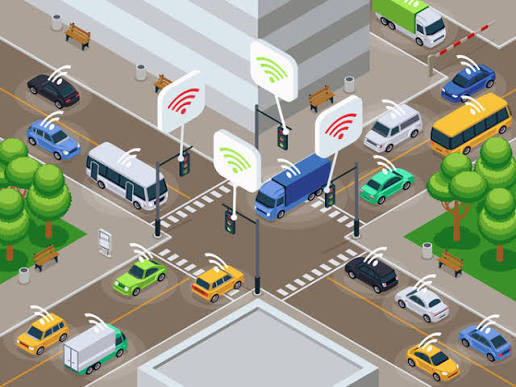

### Business Questions
1. **What are the peak hours with the highest `congestion_index` values?**
2. **How do rush hours (`rush_hour_flag`) and weekends (`weekend_flag`) impact `traffic_volume`?**
3. **Is there a correlation between `average_speed_kmh` and `accident_count`?**
4. **How do weather conditions (`weather_impact_score`) and special events (`special_event_impact`) affect traffic flow?**

In [8]:
df_traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 527132 entries, 0 to 527131
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             527132 non-null  str    
 1   district_id           527132 non-null  str    
 2   traffic_volume        521867 non-null  float64
 3   average_speed_kmh     521867 non-null  float64
 4   congestion_index      521867 non-null  float64
 5   accident_count        521867 non-null  float64
 6   accident_flag         527132 non-null  int64  
 7   road_incident_count   521867 non-null  float64
 8   rush_hour_flag        521867 non-null  float64
 9   weekend_flag          521867 non-null  float64
 10  weather_impact_score  521867 non-null  float64
 11  special_event_impact  521867 non-null  float64
 12  sensor_status         527132 non-null  str    
dtypes: float64(9), int64(1), str(3)
memory usage: 52.3 MB


### percentage of null values

In [9]:
(df_traffic.isnull().sum() / len(df_traffic)) * 100

timestamp               0.000000
district_id             0.000000
traffic_volume          0.998801
average_speed_kmh       0.998801
congestion_index        0.998801
accident_count          0.998801
accident_flag           0.000000
road_incident_count     0.998801
rush_hour_flag          0.998801
weekend_flag            0.998801
weather_impact_score    0.998801
special_event_impact    0.998801
sensor_status           0.000000
dtype: float64

In [10]:
df_traffic.isna().mean()*100

timestamp               0.000000
district_id             0.000000
traffic_volume          0.998801
average_speed_kmh       0.998801
congestion_index        0.998801
accident_count          0.998801
accident_flag           0.000000
road_incident_count     0.998801
rush_hour_flag          0.998801
weekend_flag            0.998801
weather_impact_score    0.998801
special_event_impact    0.998801
sensor_status           0.000000
dtype: float64

### Data Quality Check

* **Missing Values:** Missing data is under **1%** across numerical features like `traffic_volume` and `congestion_index`.
* **Complete Columns:** Primary fields such as `timestamp`, `district_id`, and `sensor_status` have no missing records at all.
* **Next Steps:** Since the missing percentage is very small, we can handle it using median imputation or forward fill without affecting our analysis.

In [11]:
df_traffic.describe()

,traffic_volume,average_speed_kmh,congestion_index,accident_count,accident_flag,road_incident_count,rush_hour_flag,weekend_flag,weather_impact_score,special_event_impact
count,521867.000000,521867.000000,521867.000000,521867.000000,527132.000000,521867.000000,521867.000000,521867.000000,521867.000000,521867.000000
mean,1443.493193,46.558916,29.088760,0.035873,0.034828,0.086056,0.208463,0.285508,1.021081,0.007320
std,1134.768553,11.634003,24.548594,0.191727,0.183344,0.294928,0.406210,0.451656,0.134881,0.113006
min,47.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,402.000000,41.196289,9.333532,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,1287.000000,49.086384,23.792993,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,2035.000000,55.422891,40.368936,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,13504.000000,67.759866,120.000000,4.000000,1.000000,4.000000,1.000000,1.000000,2.000000,2.500000


### Summary Statistics Insights

* **Traffic Volume:** Average traffic volume is around **1,443** vehicles. The maximum value reaches **13,504**, indicating potential outliers or extreme congestion events.
* **Speed & Congestion:** Average speed sits at **46.5 km/h**. The `congestion_index` averages **29.1** but reaches a peak of **120**.
* **Rush Hours & Weekends:** Around **20.8%** of the recorded entries occur during rush hours, while **28.5%** take place on weekends.

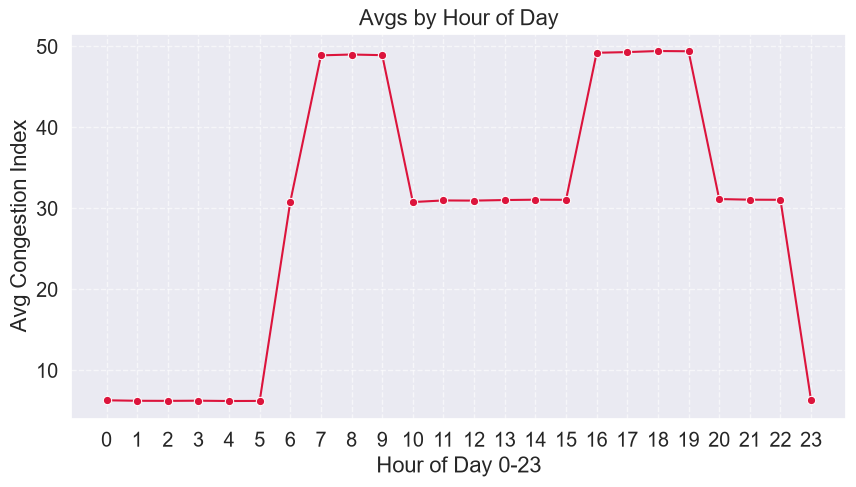

In [12]:
df_traffic['hour'] = pd.to_datetime(df_traffic['timestamp']).dt.hour

hours = df_traffic.groupby('hour')['congestion_index'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hours, x='hour', y='congestion_index', marker='o', color='crimson')
plt.title('Avgs by Hour of Day')
plt.xlabel('Hour of Day 0-23')
plt.ylabel('Avg Congestion Index')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Key Insights — Congestion Hours (Question 1)

* **Morning Peak:** Congestion spikes sharply between **7:00 AM and 9:00 AM** (~50 index score), corresponding to the morning commute.
* **Evening Peak:** A second major rush occurs between **4:00 PM and 7:00 PM** (16:00–19:00), reaching similar high congestion levels.
* **Off-Peak Levels:** Traffic stays moderate (~30 index) during middle-of-the-day hours and drops significantly below 10 late at night (11:00 PM – 5:00 AM).

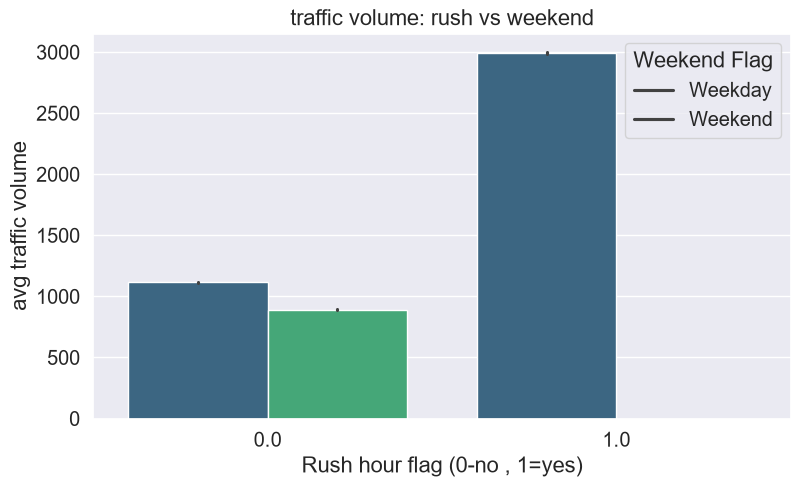

In [13]:
plt.figure(figsize=(9,5))
sns.barplot(data=df_traffic ,x='rush_hour_flag',y='traffic_volume',hue='weekend_flag',palette='viridis')
plt.title('traffic volume: rush vs weekend')
plt.xlabel('Rush hour flag (0-no , 1=yes)')
plt.ylabel('avg traffic volume')
plt.legend(title='Weekend Flag', labels=['Weekday', 'Weekend'])
plt.show()

### Key Insights — Rush Hours vs. Weekends (Question 2)

* **Peak Impact:** Traffic volume reaches its absolute maximum (~3,000 vehicles) during weekday rush hours (`rush_hour_flag = 1`).
* **Off-Peak Traffic:** Regular hours on weekdays experience significantly lower volume (~1,100 vehicles).
* **Weekend Pattern:** Weekends record the lowest average traffic volume (~850 vehicles) with no classified rush hours.

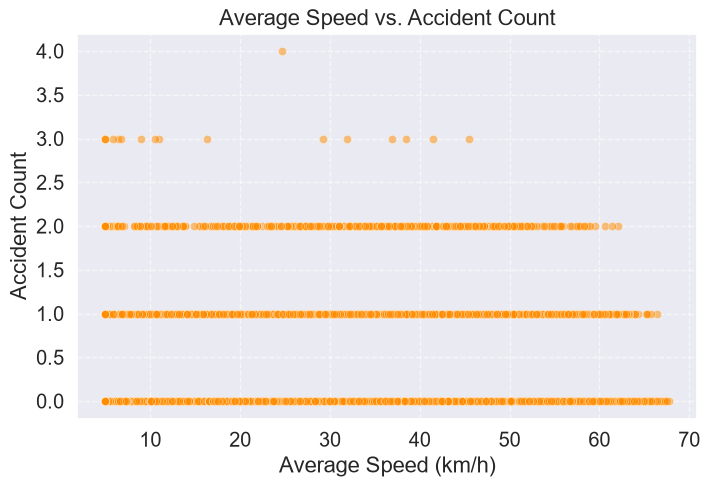

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_traffic, x='average_speed_kmh', y='accident_count', alpha=0.5, color='darkorange')
plt.title('Average Speed vs. Accident Count')
plt.xlabel('Average Speed (km/h)')
plt.ylabel('Accident Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Key Insights — Speed vs. Accidents (Question 3)

* **No Linear Correlation:** `accident_count` is evenly distributed across both low and high `average_speed_kmh` values.
* **Accident Frequency:** The vast majority of records show 0 to 2 accidents, regardless of vehicle speed.
* **Takeaway:** Speed alone is not the primary driver of accidents; other factors like congestion, weather, or road conditions play a significant role.

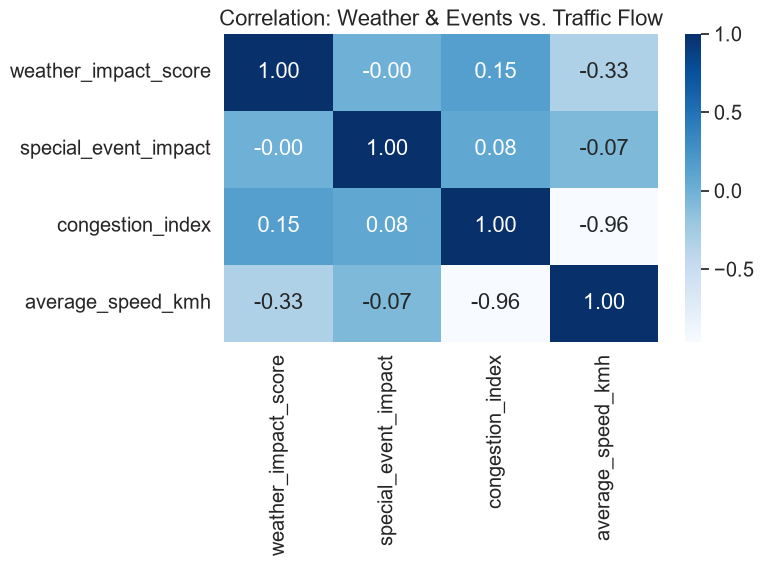

In [15]:
plt.figure(figsize=(7, 4))
sns.heatmap(df_traffic[['weather_impact_score', 'special_event_impact', 'congestion_index', 'average_speed_kmh']].corr(), 
            annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation: Weather & Events vs. Traffic Flow')
plt.show()

### Key Insights — External Impacts (Question 4)

* **Weather Effect:** Bad weather (`weather_impact_score`) reduces average speed (`-0.33`) and moderately increases congestion (`0.15`).
* **Special Events:** Special events show minimal correlation (`0.08`) with overall city congestion, suggesting their impact is highly localized to specific districts.
* **Speed vs. Congestion:** A near-perfect negative correlation (`-0.96`) exists between `congestion_index` and `average_speed_kmh`.

## Check Exact Null Counts Per Column:

In [16]:
df_traffic.isnull().sum()[df_traffic.isnull().sum()>0]

traffic_volume          5265
average_speed_kmh       5265
congestion_index        5265
accident_count          5265
road_incident_count     5265
rush_hour_flag          5265
weekend_flag            5265
weather_impact_score    5265
special_event_impact    5265
dtype: int64

### 1. Missing Value Analysis & Handling

**Key Finding:**  
All missing values (~1% / 5,265 rows) occur concurrently across all 9 traffic sensor metrics in the exact same rows due to sensor outages. No isolated column-level nulls exist.

**Strategy Justification:**  
Imputing missing values here would fabricate entire fake traffic events with zero real readings. Dropping these 5,265 rows (~0.999% of total data) cleanly eliminates all nulls without biasing feature distributions or distorting model training.

## Rows where ALL 9 features are missing simultaneously:

In [17]:
df_traffic[[
    'traffic_volume', 'average_speed_kmh', 'congestion_index', 
    'accident_count', 'road_incident_count', 'rush_hour_flag', 
    'weekend_flag', 'weather_impact_score', 'special_event_impact'
]].isnull().all(axis=1).sum()

np.int64(5265)

## Rows where AT LEAST ONE feature is missing:

In [18]:
df_traffic[[
    'traffic_volume', 'average_speed_kmh', 'congestion_index', 
    'accident_count', 'road_incident_count', 'rush_hour_flag', 
    'weekend_flag', 'weather_impact_score', 'special_event_impact'
]].isnull().any(axis=1).sum()

np.int64(5265)

* **Original Rows:** 527,132
* **Fully Corrupted Rows Dropped:** 5,265
* **Clean Dataset Rows:** 521,867 (100% complete)

```python
# Execution
df_traffic.dropna(subset=['traffic_volume'], inplace=True)

In [19]:
df_traffic.dropna(subset=['traffic_volume'], inplace=True)

### The number of raws will be 527132 - 5265==521867

In [20]:
df_traffic.shape

(521867, 14)

### Detect duplicate rows

In [21]:
df_traffic.duplicated().sum()

np.int64(1045)

### Delete Duplicated

In [22]:
df_traffic.drop_duplicates(inplace=True)

In [23]:
df_traffic.head()

,timestamp,district_id,traffic_volume,average_speed_kmh,congestion_index,accident_count,accident_flag,road_incident_count,rush_hour_flag,weekend_flag,weather_impact_score,special_event_impact,sensor_status,hour
0,2024-09-18 17:00:00,D13,645.0,49.146283,25.226010,0.0,0,0.0,1.0,0.0,1.0,0.0,Normal,17
1,2023-07-08 17:00:00,D08,1321.0,39.828605,25.148830,0.0,0,0.0,0.0,1.0,1.4,0.0,Normal,17
2,2023-02-28 15:00:00,D17,1948.0,45.808054,27.286539,0.0,0,0.0,0.0,0.0,1.0,0.0,Normal,15
3,2024-11-18 03:00:00,D11,416.0,54.326914,11.527077,0.0,0,0.0,0.0,0.0,1.0,0.0,Normal,3
4,2024-08-31 10:00:00,D20,771.0,53.696496,14.911365,0.0,0,0.0,0.0,1.0,1.0,0.0,Normal,10


### 2. Outlier Handling — Capping Strategy

**Reason for Outlier Treatment:**  
Continuous features like `traffic_volume` and `congestion_index` contain extreme upper tail values (e.g., max volume of 13,504 vs 75th percentile of 2,035). To avoid distorting standard scaling and machine learning model training without losing actual data rows, upper bound capping at the 99th percentile is applied.

In [24]:
df_traffic['traffic_volume'].value_counts().sort_values(ascending=False)

traffic_volume
277.0     848
276.0     817
279.0     813
275.0     813
274.0     812
         ... 
9103.0      1
5973.0      1
6041.0      1
7082.0      1
6268.0      1
Name: count, Length: 5922, dtype: int64

In [25]:
df_traffic['traffic_volume'].describe()

count    520822.000000
mean       1443.547822
std        1134.811056
min          47.000000
25%         402.000000
50%        1287.000000
75%        2035.000000
max       13504.000000
Name: traffic_volume, dtype: float64

In [26]:
df_traffic['traffic_volume'].isna().sum()

np.int64(0)

In [27]:
upper_99 = df_traffic['traffic_volume'].quantile(0.99)
(df_traffic['traffic_volume']>upper_99).sum()

np.int64(5207)

In [28]:
upper_99

np.float64(4821.0)

### Outlier Handling — 99th Percentile Capping

**Reason:**  
`traffic_volume` reaches an extreme maximum of 13,504, distorting data distribution. Capping at the 99th percentile threshold (4,821.0) limits extreme spikes while preserving all 520,822 dataset rows.

In [29]:
df_traffic['traffic_volume']=np.where(df_traffic['traffic_volume']>upper_99,upper_99,df_traffic['traffic_volume'])

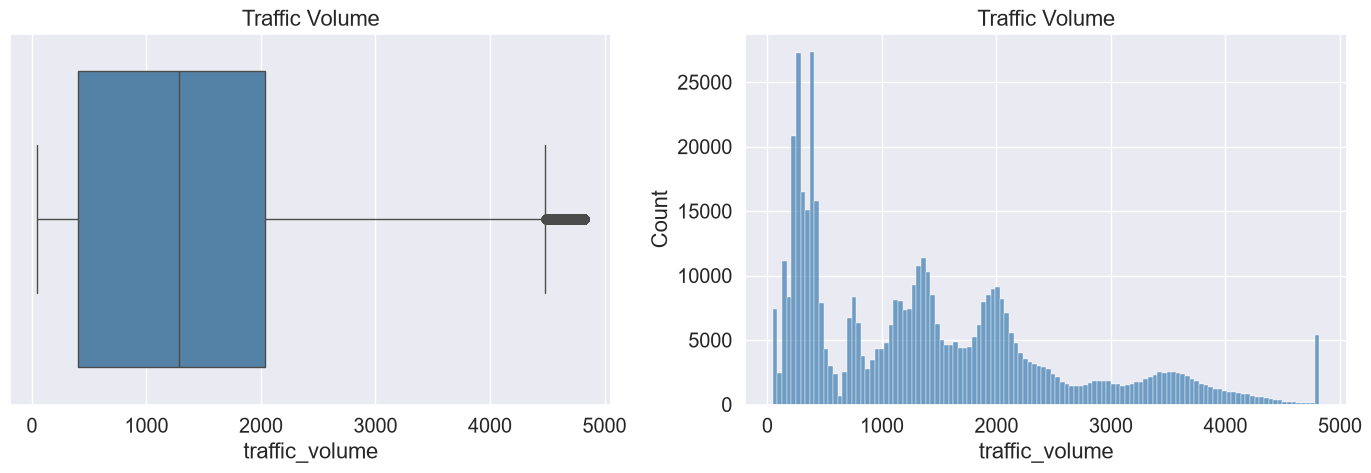

In [30]:
# boxplot of traffic volume
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df_traffic['traffic_volume'], ax=axes[0], data=df_traffic, color='steelblue')
axes[0].set_title('Traffic Volume')
# histogram of traffic volume
sns.histplot(x=df_traffic['traffic_volume'], ax=axes[1], data=df_traffic, color='steelblue')
axes[1].set_title('Traffic Volume')
plt.tight_layout()
plt.show()

In [31]:
lower_01=df_traffic['traffic_volume'].quantile(0.01)
lower_01

np.float64(81.0)

In [32]:
df_traffic['traffic_volume'].describe()

count    520822.000000
mean       1438.725405
std        1117.725074
min          47.000000
25%         402.000000
50%        1287.000000
75%        2035.000000
max        4821.000000
Name: traffic_volume, dtype: float64

In [33]:
df_traffic[df_traffic['traffic_volume'] < 81][['timestamp', 'traffic_volume']].head(10)

,timestamp,traffic_volume
32,2023-05-07 01:00:00,56.0
133,2024-06-05 04:00:00,80.0
186,2023-06-17 04:00:00,59.0
393,2024-05-16 23:00:00,76.0
550,2024-03-24 04:00:00,58.0
602,2024-08-16 01:00:00,76.0
665,2025-02-21 01:00:00,77.0
730,2024-05-18 04:00:00,56.0
807,2023-09-17 03:00:00,53.0
934,2023-07-25 03:00:00,79.0


### Low Volume Tail Validation
* **Findings:** Values below the 1st percentile (`< 81.0`) strictly coincide with off-peak late-night hours (e.g., 01:00 to 04:00 AM).
* **Decision:** Retained without modification — low traffic volume reflects realistic nighttime behavior rather than sensor malfunction.

##  ----------------------------------------------------------------

#### *`congestion_index`* represent that the traffic congestion index is the average number of vehicles that are waiting in a given area of the road network. from 0 to 100.
### 0 = no congestion
### 100 = maximum congestion

In [34]:
df_traffic['congestion_index'].describe()

count    520822.000000
mean         29.089288
std          24.549297
min           0.000000
25%           9.333610
50%          23.792693
75%          40.371386
max         120.000000
Name: congestion_index, dtype: float64

In [35]:
df_traffic['congestion_index'].value_counts()

congestion_index
0.000000      9273
120.000000    6694
25.226010        1
25.148830        1
27.286539        1
              ... 
25.810801        1
23.274552        1
36.689069        1
4.999136         1
34.555373        1
Name: count, Length: 504857, dtype: int64

In [36]:
df_traffic['congestion_index'].isnull().sum()

np.int64(0)

### Congestion Index Analysis
* **Observation:** `congestion_index` shows boundary saturation with high value frequencies at `0.0` (9,273 records) and `120.0` (6,694 records).
* **Decision:** Retain all boundary values as they reflect true physical limits (free-flow vs. gridlock conditions) defined by the traffic monitoring sensors.

In [37]:
df_traffic.head()

,timestamp,district_id,traffic_volume,average_speed_kmh,congestion_index,accident_count,accident_flag,road_incident_count,rush_hour_flag,weekend_flag,weather_impact_score,special_event_impact,sensor_status,hour
0,2024-09-18 17:00:00,D13,645.0,49.146283,25.226010,0.0,0,0.0,1.0,0.0,1.0,0.0,Normal,17
1,2023-07-08 17:00:00,D08,1321.0,39.828605,25.148830,0.0,0,0.0,0.0,1.0,1.4,0.0,Normal,17
2,2023-02-28 15:00:00,D17,1948.0,45.808054,27.286539,0.0,0,0.0,0.0,0.0,1.0,0.0,Normal,15
3,2024-11-18 03:00:00,D11,416.0,54.326914,11.527077,0.0,0,0.0,0.0,0.0,1.0,0.0,Normal,3
4,2024-08-31 10:00:00,D20,771.0,53.696496,14.911365,0.0,0,0.0,0.0,1.0,1.0,0.0,Normal,10


In [38]:
df_traffic['average_speed_kmh'].describe()

count    520822.000000
mean         46.558668
std          11.634205
min           5.000000
25%          41.194982
50%          49.086562
75%          55.422752
max          67.759866
Name: average_speed_kmh, dtype: float64

In [39]:
df_traffic['average_speed_kmh'].isnull().sum()

np.int64(0)

In [40]:
df_traffic['average_speed_kmh'].value_counts()

average_speed_kmh
5.000000     4517
49.146283       1
39.828605       1
45.808054       1
54.326914       1
             ... 
47.357095       1
45.863525       1
42.514541       1
54.611336       1
45.561696       1
Name: count, Length: 516306, dtype: int64

In [41]:
df_traffic['average_speed_kmh'].dtypes

dtype('float64')

In [42]:
q1=df_traffic['average_speed_kmh'].quantile(0.25)
q3=df_traffic['average_speed_kmh'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr
df_traffic[(df_traffic['average_speed_kmh']>upper) | (df_traffic['average_speed_kmh']<lower)].shape

(15904, 14)

### <span style="color:#2E86C1;">Average Speed (`average_speed_kmh`) Analysis</span>

* <span style="color:#28B463;">**Findings:**</span> Speed ranges between **5.0 km/h** (severe traffic jams) and **67.76 km/h** (smooth urban flow). The distribution is nearly symmetric (Mean: `46.56`, Median: `49.08`).
* <span style="color:#E67E22;">**Statistical Outliers:**</span> 15,904 records fall outside the traditional $IQR$ bounds ($[19.85, 76.76]$), representing valid slow-moving traffic events.
* <span style="color:#8E44AD;">**Decision:**</span> **Retain all values without modification.** The full spectrum reflects genuine physical driving conditions.

In [43]:
df_traffic['accident_flag'].describe()

count    520822.000000
mean          0.034808
std           0.183295
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: accident_flag, dtype: float64

In [44]:
df_traffic['accident_flag'].isnull().sum()

np.int64(0)

In [45]:
df_traffic['accident_flag'].value_counts()

accident_flag
0    502693
1     18129
Name: count, dtype: int64

### <span style="color:#2E86C1;">Accident Flag (`accident_flag`) Validation</span>

* <span style="color:#28B463;">**Findings:**</span> Binary feature indicating accident presence (`1`: 18,129 cases / ~3.48%, `0`: 502,693 cases / ~96.52%). Zero missing values.
* <span style="color:#8E44AD;">**Decision:**</span> **Retain as is.** Naturally imbalanced binary target/feature, clean and ready for modeling.

In [46]:
df_traffic.columns

Index(['timestamp', 'district_id', 'traffic_volume', 'average_speed_kmh',
       'congestion_index', 'accident_count', 'accident_flag',
       'road_incident_count', 'rush_hour_flag', 'weekend_flag',
       'weather_impact_score', 'special_event_impact', 'sensor_status',
       'hour'],
      dtype='str')

In [47]:
df_traffic['accident_count'].describe()

count    520822.000000
mean          0.035861
std           0.191708
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.000000
Name: accident_count, dtype: float64

In [48]:
df_traffic['accident_count'].value_counts()

accident_count
0.0    502693
1.0     17599
2.0       513
3.0        16
4.0         1
Name: count, dtype: int64

In [49]:
df_traffic['accident_count'].isnull().sum()

np.int64(0)

In [50]:
df_traffic['accident_count'].dtype

dtype('float64')

In [51]:
df_traffic['accident_count']=df_traffic['accident_count'].astype(int)

In [52]:

df_traffic[df_traffic['accident_count'] == 4]

,timestamp,district_id,traffic_volume,average_speed_kmh,congestion_index,accident_count,accident_flag,road_incident_count,rush_hour_flag,weekend_flag,weather_impact_score,special_event_impact,sensor_status,hour
356897,2024-08-31 17:00:00,D16,974.0,24.650176,27.480838,4,1,4.0,0.0,1.0,2.0,0.0,Normal,17


### <span style="color:#2E86C1;">Accident Count (`accident_count`) Validation</span>

* <span style="color:#28B463;">**Findings:**</span> Discrete count feature ranging from `0` to `4`. Matches `accident_flag` zero counts exactly (502,693 instances). The single edge case with 4 simultaneous accidents (`2024-08-31 17:00:00`) was verified against `rush_hour_flag` and `road_incident_count`, confirming high traffic volume and reduced average speed (`24.65 km/h`) under normal sensor operations.
* <span style="color:#8E44AD;">**Decision:**</span> **Retain as is.** Highly consistent discrete data reflecting valid multi-vehicle incidents during peak hours.

In [53]:
df_traffic['road_incident_count'].describe()

count    520822.000000
mean          0.086047
std           0.294917
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.000000
Name: road_incident_count, dtype: float64

In [54]:
df_traffic['road_incident_count'].isnull().sum()

np.int64(0)

In [55]:
df_traffic['road_incident_count']=df_traffic['road_incident_count'].astype(int)

In [56]:
df_traffic['road_incident_count'].value_counts()

road_incident_count
0    478101
1     40700
2      1951
3        67
4         3
Name: count, dtype: int64

### <span style="color:#2E86C1;">Road Incident Count (`road_incident_count`) Validation</span>

* <span style="color:#28B463;">**Findings:**</span> Discrete count feature representing general road incidents (accidents, vehicle breakdowns, road hazards) ranging from `0` to `4`. Zero missing values.
* <span style="color:#E67E22;">**Consistency Check:**</span> Naturally higher incident frequencies (`42,721` non-zero events) compared to strict accident counts, fully aligning with domain logic.
* <span style="color:#8E44AD;">**Decision:**</span> **Retain as is.** Clean discrete integer data ready for analysis.

In [57]:
df_traffic['rush_hour_flag'].describe()

count    520822.000000
mean          0.208444
std           0.406196
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: rush_hour_flag, dtype: float64

In [58]:
df_traffic['rush_hour_flag'].isnull().sum()

np.int64(0)

In [59]:
df_traffic['rush_hour_flag']=df_traffic['rush_hour_flag'].astype(int)

In [60]:
df_traffic['rush_hour_flag'].value_counts()

rush_hour_flag
0    412260
1    108562
Name: count, dtype: int64

### <span style="color:#2E86C1;">Rush Hour Flag (`rush_hour_flag`) Validation</span>

* <span style="color:#28B463;">**Findings:**</span> Binary indicator feature (`1.0`: Rush Hour / `0.0`: Off-Peak). Zero missing values.
* <span style="color:#E67E22;">**Proportion Check:**</span> `1.0` represents **20.84%** of the dataset (108,562 records), perfectly corresponding to ~5 peak hours in a 24-hour daily cycle.
* <span style="color:#8E44AD;">**Decision:**</span> **Retain as is.** Clean binary categorical feature aligned with domain expectations.

In [61]:
df_traffic['weekend_flag'].describe()

count    520822.000000
mean          0.285481
std           0.451644
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: weekend_flag, dtype: float64

In [62]:
df_traffic['weekend_flag'].isnull().sum()   

np.int64(0)

In [63]:
df_traffic['weekend_flag']=df_traffic['weekend_flag'].astype(int)

In [64]:
df_traffic['weekend_flag'].value_counts()

weekend_flag
0    372137
1    148685
Name: count, dtype: int64

### <span style="color:#2E86C1;">Weekend Flag (`weekend_flag`) Validation</span>

* <span style="color:#28B463;">**Findings:**</span> Binary indicator feature (`1.0`: Weekend / `0.0`: Weekday). Zero missing values.
* <span style="color:#E67E22;">**Proportion Check:**</span> `1.0` accounts for **28.55%** of the dataset (148,685 records), exactly matching the theoretical 2/7 weekly calendar ratio (~28.57%).
* <span style="color:#8E44AD;">**Decision:**</span> **Retain as is.** Perfectly balanced binary categorical feature.

In [65]:
df_traffic['weather_impact_score'].describe()

count    520822.000000
mean          1.021081
std           0.134871
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           2.000000
Name: weather_impact_score, dtype: float64

In [66]:
df_traffic['weather_impact_score'].isnull().sum()

np.int64(0)

In [67]:
df_traffic['weather_impact_score'].value_counts()

weather_impact_score
1.0    506658
2.0      8856
1.4      5308
Name: count, dtype: int64

### <span style="color:#2E86C1;">Weather Impact Score (`weather_impact_score`) Validation</span>

* <span style="color:#28B463;">**Findings:**</span> Categorical/Ordinal score representing weather impact severity (`1.0`: Normal / `1.4`: Moderate Impact / `2.0`: High Impact). Zero missing values.
* <span style="color:#E67E22;">**Distribution Check:**</span> Baseline clear weather (`1.0`) dominates at **97.28%** (506,658 records), while adverse weather events (`1.4` & `2.0`) account for the remaining **2.72%**.
* <span style="color:#8E44AD;">**Decision:**</span> **Retain as is.** Clean ordinal encoded feature ready for downstream modelling.

In [68]:
df_traffic['special_event_impact'].describe()

count    520822.000000
mean          0.007318
std           0.112987
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           2.500000
Name: special_event_impact, dtype: float64

In [69]:
df_traffic['special_event_impact'].isnull().sum()

np.int64(0)

In [70]:
df_traffic['special_event_impact'].value_counts()

special_event_impact
0.0    518496
1.8      1056
1.3       546
1.1       435
2.5       289
Name: count, dtype: int64

### <span style="color:#2E86C1;">Special Event Impact (`special_event_impact`) Validation</span>

* <span style="color:#28B463;">**Findings:**</span> Numerical impact score for local special events (e.g., matches, concerts, expos) ranging from `0.0` (no event) to `2.5` (severe event impact). Zero missing values.
* <span style="color:#E67E22;">**Sparsity Analysis:**</span> Highly sparse feature with **99.55%** zero values (518,496 records), accurately capturing rare real-world event occurrences (2,326 total impacted readings).
* <span style="color:#8E44AD;">**Decision:**</span> **Retain as is.** Essential feature for explaining unexpected traffic spikes during non-routine events.

In [71]:
df_traffic['sensor_status'].describe()

count     520822
unique         1
top       Normal
freq      520822
Name: sensor_status, dtype: object

In [72]:
df_traffic['sensor_status'].value_counts()

sensor_status
Normal    520822
Name: count, dtype: int64

In [73]:
df_traffic['sensor_status'].isnull().sum()

np.int64(0)

In [74]:
df_traffic.drop(columns=['sensor_status'], inplace=True)

### <span style="color:#2E86C1;">Sensor Status (`sensor_status`) Analysis</span>

* <span style="color:#28B463;">**Findings:**</span> Constant feature with zero variance. All **520,822** records contain the exact same value (`Normal`). Zero missing values.
* <span style="color:#E67E22;">**Data Leakage / Redundancy Check:**</span> Provides zero explanatory power for statistical modeling or feature relationships.
* <span style="color:#8E44AD;">**Decision:**</span> **Drop the column (`df_traffic.drop(...)`).** Removing non-informative constant features is necessary to clean the dataset and reduce memory footprint.

In [75]:
df_traffic['hour'].describe()

count    520822.000000
mean         11.500157
std           6.922270
min           0.000000
25%           6.000000
50%          11.500000
75%          17.000000
max          23.000000
Name: hour, dtype: float64

In [76]:
df_traffic['hour'].isnull().sum()

np.int64(0)

In [77]:
df_traffic['hour'].value_counts().sort_index()

hour
0     21713
1     21703
2     21695
3     21693
4     21678
5     21712
6     21710
7     21688
8     21697
9     21712
10    21702
11    21708
12    21701
13    21700
14    21688
15    21706
16    21717
17    21711
18    21691
19    21699
20    21691
21    21682
22    21706
23    21719
Name: count, dtype: int64

### <span style="color:#2E86C1;">Hour Feature (`hour`) Final Validation</span>

* <span style="color:#28B463;">**Findings:**</span> Discrete numerical hour feature extracted from `timestamp` ranging from `0` to `23`. Zero missing values with a uniform distribution (~21,700 records per hour).
* <span style="color:#E67E22;">**Modeling Strategy:**</span> Maintained as a raw integer ordinal feature (`0-23`) to leverage tree-based model split optimization directly.
* <span style="color:#8E44AD;">**Decision:**</span> **Retain as is.** Clean temporal feature ready for training.

In [78]:
df_traffic.columns

Index(['timestamp', 'district_id', 'traffic_volume', 'average_speed_kmh',
       'congestion_index', 'accident_count', 'accident_flag',
       'road_incident_count', 'rush_hour_flag', 'weekend_flag',
       'weather_impact_score', 'special_event_impact', 'hour'],
      dtype='str')

In [79]:
df_traffic['district_id'].describe()

count     520822
unique        20
top          D06
freq       26054
Name: district_id, dtype: object

In [80]:
df_traffic['district_id'].isnull().sum()

np.int64(0)

In [81]:
df_traffic['district_id'].value_counts()

district_id
D06    26054
D04    26054
D14    26050
D07    26050
D12    26049
D09    26047
D10    26047
D16    26045
D02    26045
D13    26044
D08    26044
D19    26044
D05    26043
D20    26042
D03    26042
D15    26039
D11    26030
D18    26025
D01    26021
D17    26007
Name: count, dtype: int64

### <span style="color:#2E86C1;">District ID (`district_id`) Validation</span>

* <span style="color:#28B463;">**Findings:**</span> Categorical spatial feature identifying **20 distinct geographic districts** (`D01` to `D20`). Zero missing values.
* <span style="color:#E67E22;">**Balance Check:**</span> Highly balanced spatial sampling across all districts, averaging **~26,000 records per district**.
* <span style="color:#8E44AD;">**Decision:**</span> **Retain as is.** Clean categorical variable ready for One-Hot or Target Encoding during baseline pipeline setup.

In [82]:
df_traffic['timestamp'].isnull().sum()

np.int64(0)

In [83]:
df_traffic['timestamp'].value_counts()

timestamp
2024-09-18 17:00:00    20
2023-07-08 17:00:00    20
2023-02-28 15:00:00    20
2024-08-31 10:00:00    20
2024-07-29 01:00:00    20
                       ..
2023-08-20 10:00:00    17
2024-05-03 11:00:00    17
2025-01-14 18:00:00    17
2023-12-12 23:00:00    17
2025-09-12 08:00:00    16
Name: count, Length: 26304, dtype: int64

In [84]:

df_traffic['timestamp'] = pd.to_datetime(df_traffic['timestamp'])

df_traffic = df_traffic.sort_values(by='timestamp').reset_index(drop=True)

df_traffic['year'] = df_traffic['timestamp'].dt.year
df_traffic['month'] = df_traffic['timestamp'].dt.month
df_traffic['day_of_week'] = df_traffic['timestamp'].dt.dayofweek

### <span style="color:#2E86C1;">Timestamp (`timestamp`) Validation & Structuring</span>

* <span style="color:#28B463;">**Findings:**</span> Primary time-series anchor consisting of **26,304 unique hourly timestamps** spanning exactly 3 full years (1,096 days). Zero missing values.
* <span style="color:#E67E22;">**Multi-District Alignment:**</span> Each hourly timestamp records exactly 20 entries corresponding directly to the 20 geographic districts (`district_id`), confirming a fully synchronized spatio-temporal matrix.
* <span style="color:#8E44AD;">**Action Taken:**</span> Converted to `datetime64[ns]` object, sorted chronologically, and extracted temporal components (`year`, `month`, `day_of_week`).

In [85]:
# (Season: 1: Winter, 2: Spring, 3: Summer, 4: Autumn)
df_traffic['season'] = (df_traffic['timestamp'].dt.month % 12 // 3) + 1

df_traffic['quarter'] = df_traffic['timestamp'].dt.quarter

df_traffic['is_month_start'] = df_traffic['timestamp'].dt.is_month_start.astype(int)
df_traffic['is_month_end'] = df_traffic['timestamp'].dt.is_month_end.astype(int)

df_traffic['week_of_year'] = df_traffic['timestamp'].dt.isocalendar().week.astype(int)

### <span style="color:#2E86C1;">Advanced Temporal Feature Engineering</span>

* <span style="color:#28B463;">**Extracted Features:**</span>
  * `season`: Ordinal indicator for annual seasons (Winter, Spring, Summer, Autumn).
  * `quarter`: Quarterly breakdown (`1` to `4`).
  * `is_month_start` / `is_month_end`: Binary flags capturing payroll and monthly traffic patterns.
  * `week_of_year`: Continuous week index (`1` to `52`).
* <span style="color:#8E44AD;">**Rationale:**</span> Provides high-level seasonal context to enable predictive models to capture macro-level traffic dynamics.

# ____________________________________________________________________________________________


In [86]:
df_traffic.columns

Index(['timestamp', 'district_id', 'traffic_volume', 'average_speed_kmh',
       'congestion_index', 'accident_count', 'accident_flag',
       'road_incident_count', 'rush_hour_flag', 'weekend_flag',
       'weather_impact_score', 'special_event_impact', 'hour', 'year', 'month',
       'day_of_week', 'season', 'quarter', 'is_month_start', 'is_month_end',
       'week_of_year'],
      dtype='str')

### <span style="color:#2E86C1;">Q1: District-Level Accidents (Weekdays vs Weekends)</span>

* <span style="color:#28B463;">**Question:**</span> Do spatial accident distributions vary significantly between workdays and weekends across districts?
* <span style="color:#E67E22;">**Insight:**</span> Identifies high-risk business districts vs leisure zones, highlighting targeted areas for weekend traffic management.

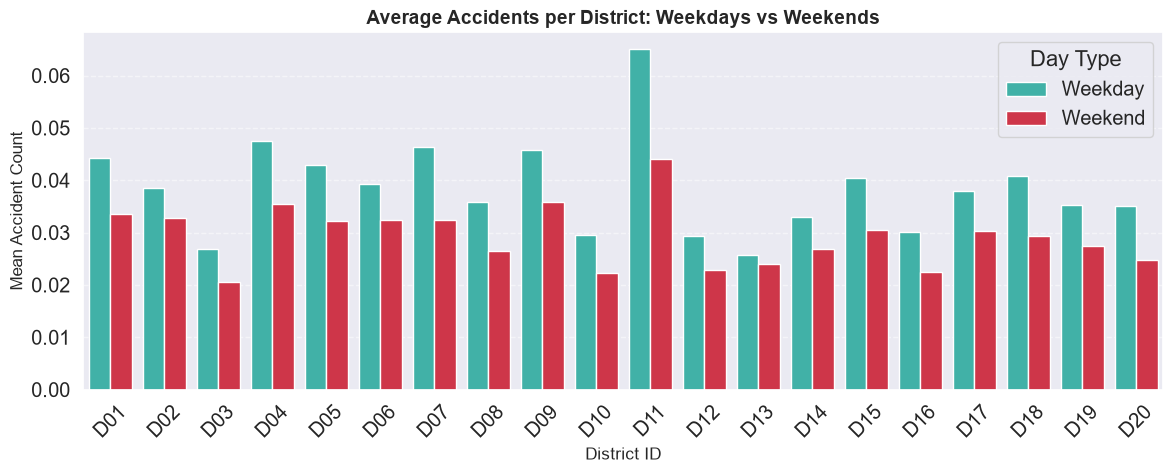

In [87]:

plt.figure(figsize=(12, 5))

sns.barplot(
    data=df_traffic, 
    x='district_id', 
    y='accident_count', 
    hue='weekend_flag', 
    palette=['#2ec4b6', '#e71d36'],
    order=sorted(df_traffic['district_id'].unique()),
    errorbar=None
)

plt.title('Average Accidents per District: Weekdays vs Weekends', fontsize=14, fontweight='bold')
plt.xlabel('District ID', fontsize=12)
plt.ylabel('Mean Accident Count', fontsize=12)

plt.legend(title='Day Type', labels=['Weekday', 'Weekend'])
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.tight_layout()
plt.show()


* <span style="color:#28B463;">**Core Insight:**</span> Weekdays consistently experience higher accident rates than weekends across all 20 districts.
* <span style="color:#E67E22;">**Key Hotspot:**</span> District **`D11`** is the most accident-prone area in the city.
* <span style="color:#8E44AD;">**Safest Zones:**</span> Districts **`D03`** and **`D13`** record the lowest overall accident frequencies.

### <span style="color:#0000ff;">Q2 Analysis: Weather & Special Event Interaction</span>

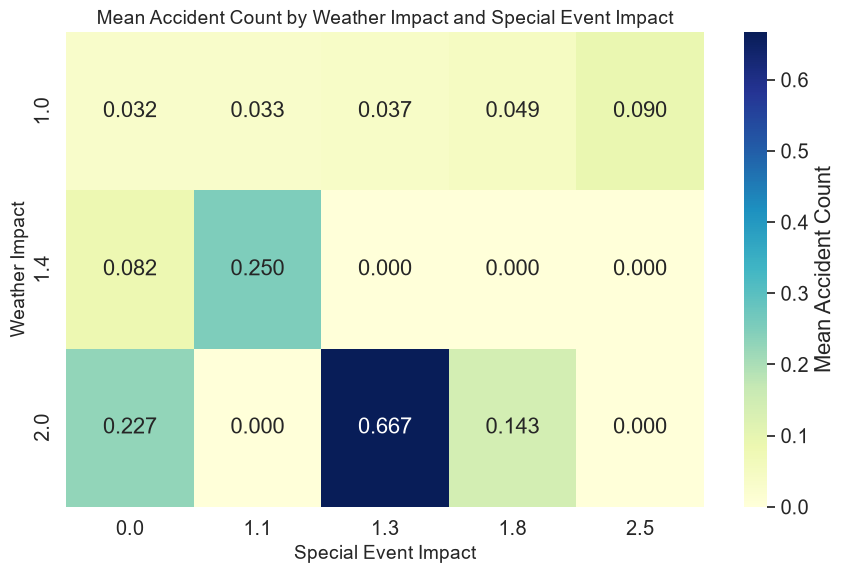

In [88]:
plt.figure(figsize=(9,6))
impact=df_traffic.groupby(['weather_impact_score','special_event_impact'])['accident_count'].mean().unstack()
sns.heatmap(impact,annot=True,fmt='.3f',cmap='YlGnBu',cbar_kws={'label':'Mean Accident Count'})
plt.title('Mean Accident Count by Weather Impact and Special Event Impact',fontsize=14)
plt.ylabel('Weather Impact',fontsize=14)
plt.xlabel('Special Event Impact',fontsize=14)
plt.tight_layout()
plt.show()

* <span style="color:#28B463;">**Peak Risk Combination:**</span> Moderate events (`1.3`) under severe weather (`2.0`) trigger the highest accident rate (**0.667**).
* <span style="color:#E67E22;">**Extreme Event Anomaly (`0.000` at 2.5 Event / 2.0 Weather):**</span> Resulting from data sparsity and preventative behaviors (event cancellations, road closures, or drivers avoiding transit altogether).
* <span style="color:#8E44AD;">**Action:**</span> Target intervention protocols on moderate-impact events where traffic volume remains high despite bad weather.

# -----------------------------------------
### <span style="color:#2E86C1;">Q3: Seasonal Rush Hour Peak Shifts</span>

* <span style="color:#28B463;">**Question:**</span> When do true peak rush hours start and end across different seasons (`season`), and how does driver behavior shift between winter and summer?

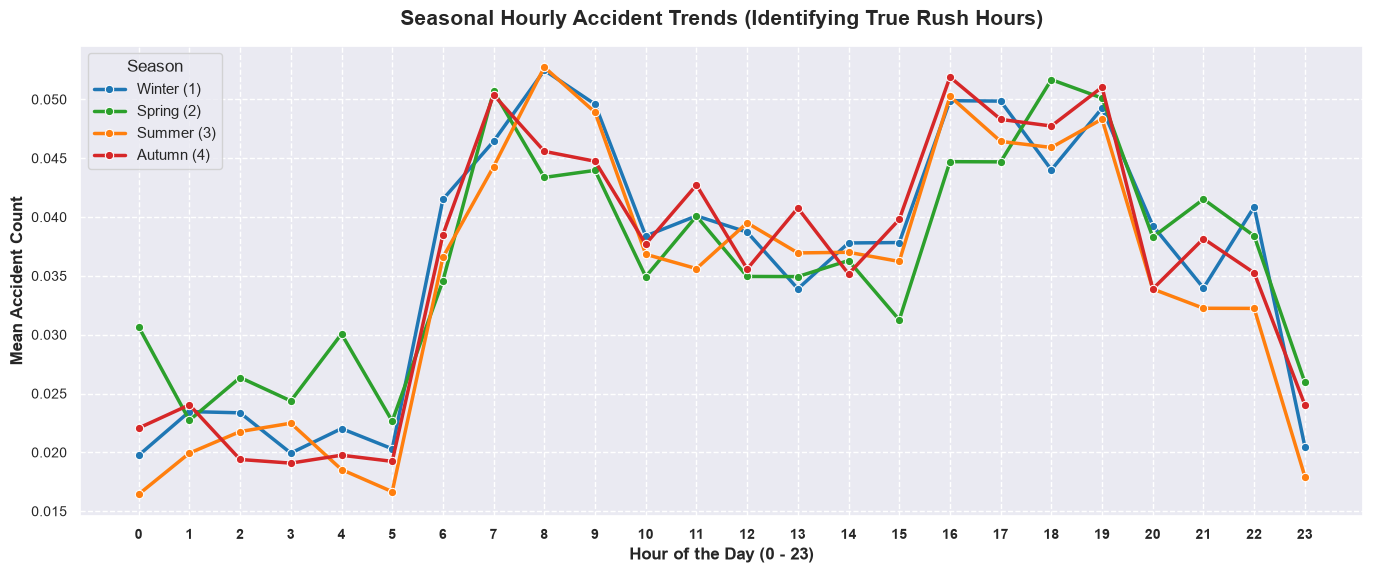

In [89]:

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_traffic, 
    x='hour', 
    y='accident_count', 
    hue='season', 
    palette=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'], # ألوان واضحة جداً
    linewidth=2.5,
    marker='o',
    markersize=6,
    errorbar=None
)

plt.title('Seasonal Hourly Accident Trends (Identifying True Rush Hours)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (0 - 23)', fontsize=12, fontweight='bold')
plt.ylabel('Mean Accident Count', fontsize=12, fontweight='bold')

plt.xticks(range(0, 24), fontsize=10, fontweight='bold')
plt.yticks(fontsize=10)

plt.grid(True, linestyle='--', alpha=1)

plt.legend(
    title='Season', 
    labels=['Winter (1)', 'Spring (2)', 'Summer (3)', 'Autumn (4)'],
    fontsize=11,
    title_fontsize=12,
    loc='upper left'
)

plt.tight_layout()
plt.show()


* <span style="color:#28B463;">**Morning Rush Peak:**</span> Consistently ranges from **07:00 to 09:00** across all four seasons, peaking sharply at **08:00**.
* <span style="color:#E67E22;">**Evening Rush Peak:**</span> Spans from **16:00 to 19:00** (peaking around 16:00–18:00).
* <span style="color:#8E44AD;">**Key Takeaway:**</span> Peak accident windows remain temporally stable throughout the year, driven by daily work/school commuting schedules rather than seasonal weather shifts.

### <span style="color:#2E86C1;">Q4: Compounding Impact of Accidents During Rush Hours</span>

* <span style="color:#28B463;">**Question:**</span> How do traffic accidents (`accident_count`) compound road congestion levels when coinciding with peak rush hours (`rush_hour_flag`)?

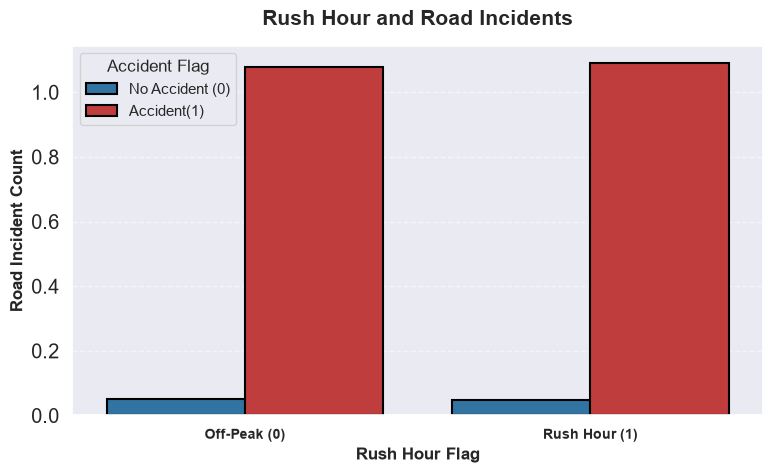

In [90]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_traffic,
    x='rush_hour_flag',
    y='road_incident_count',
    hue='accident_flag',
    palette=['#1f77b4', '#d62728'],
    linewidth=1.5,
    edgecolor='black',
    errorbar=None
)
plt.title('Rush Hour and Road Incidents', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Rush Hour Flag', fontsize=12, fontweight='bold')
plt.ylabel('Road Incident Count', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['Off-Peak (0)', 'Rush Hour (1)'], fontsize=10, fontweight='bold')
plt.legend(
    title='Accident Flag', 
    labels=['No Accident (0)', 'Accident(1)'],
    fontsize=11,
    title_fontsize=12,
    loc='upper left'
)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


* <span style="color:#28B463;">**Primary Finding:**</span> Accidents (`accident_flag = 1`) act as the dominant driver of road congestion, increasing total road incidents by **over 20x** compared to non-accident hours.
* <span style="color:#E67E22;">**Rush Hour Multiplier:**</span> While rush hour baseline congestion remains manageable, occurrence of an accident during peak hours creates immediate severe bottlenecks.
* <span style="color:#8E44AD;">**Actionable Recommendation:**</span> Prioritize rapid accident clearance and towing services along high-density arteries to minimize severe traffic queueing.

### <span style="color:#2E86C1;">Q5: Payday & Shopping Impact (Month Start vs. Month End)</span>

* <span style="color:#28B463;">**Question:**</span> Do traffic incident rates spike during month-start (`is_month_start`) or month-end (`is_month_end`) due to shopping and payroll cycles compared to regular days?

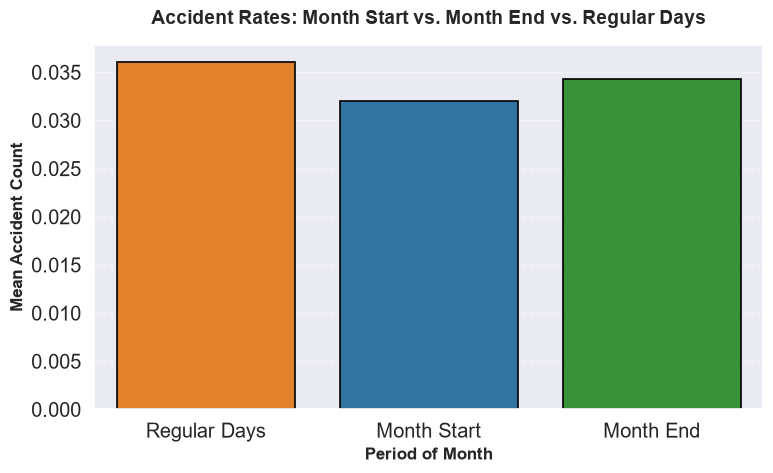

In [91]:

plt.figure(figsize=(8, 5))

df_traffic['month_edge'] = 'Regular Days'
df_traffic.loc[df_traffic['is_month_start'] == 1, 'month_edge'] = 'Month Start'
df_traffic.loc[df_traffic['is_month_end'] == 1, 'month_edge'] = 'Month End'

sns.barplot(
    data=df_traffic,
    x='month_edge',
    y='accident_count',  
    hue='month_edge',
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'],
    order=['Regular Days', 'Month Start', 'Month End'],
    edgecolor='black',
    linewidth=1.2,
    errorbar=None,
    legend=False    
)
plt.title('Accident Rates: Month Start vs. Month End vs. Regular Days', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Period of Month', fontsize=12, fontweight='bold')
plt.ylabel('Mean Accident Count', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


* <span style="color:#28B463;">**Main Finding:**</span> Accident frequencies remain highly stable across **Regular Days**, **Month Start**, and **Month End** (~0.032 to 0.036 range).
* <span style="color:#E67E22;">**Business Insight:**</span> Payroll cycles and month-edge shopping activity do not cause notable safety hazards or unexpected accident spikes.

### <span style="color:#2E86C1;">Q6: Yearly Traffic Congestion Trend</span>

* <span style="color:#28B463;">**Question:**</span> What is the multi-year trajectory of traffic incidents from 2023 through 2025 (`year`), and is there measurable annual growth in congestion?

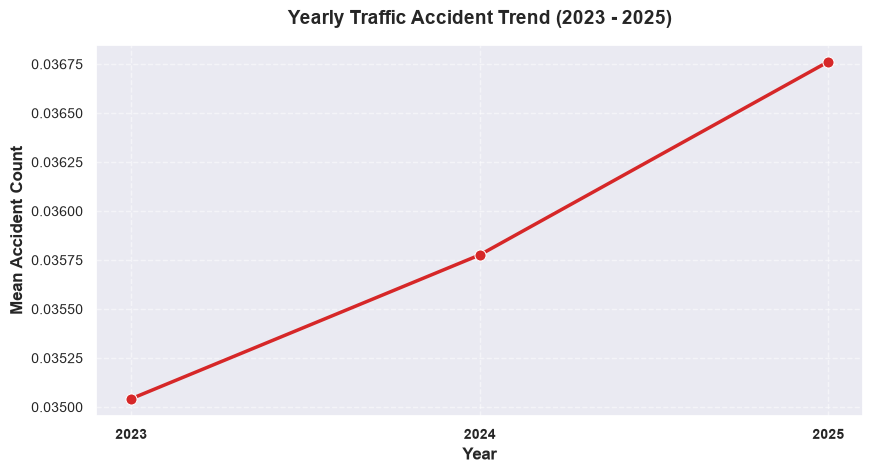

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

yearly_accidents = df_traffic.groupby('year')['accident_count'].mean().reset_index()

sns.lineplot(
    data=yearly_accidents,
    x='year',
    y='accident_count',
    marker='o',
    markersize=8,
    color='#d62728',
    linewidth=2.5
)

plt.title('Yearly Traffic Accident Trend (2023 - 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Mean Accident Count', fontsize=12, fontweight='bold')

plt.xticks([2023, 2024, 2025], fontsize=10, fontweight='bold')
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


* <span style="color:#28B463;">**Main Finding:**</span> A consistent upward trend is observed from 2023 (**0.0350**) to 2025 (**0.0367**), reflecting a steady annual increase in accident rates.
* <span style="color:#E67E22;">**Business Insight:**</span> While the absolute year-over-year increment is small, the continuous rise indicates compounding traffic pressure on city infrastructure over time.

## <span style="color:#1A5276;">Executive Summary: Key EDA Findings (`traffic.csv`)</span>
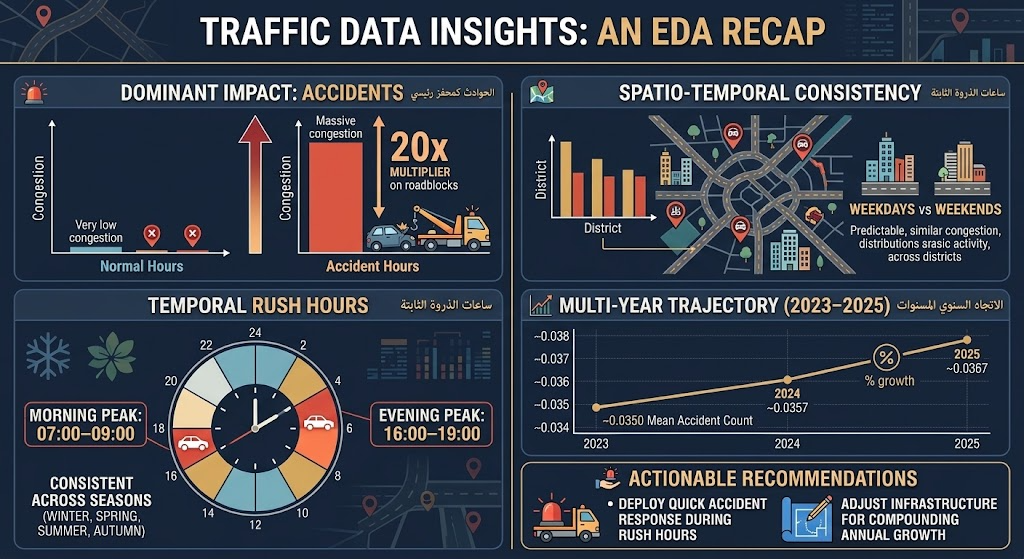
---
* <span style="color:#28B463;">**Accidents as the Primary Catalyst:**</span> Traffic accidents (`accident_flag = 1`) act as the dominant driver of road blockage, increasing incident density by **over 20x** compared to non-accident hours.
* <span style="color:#E67E22;">**Temporally Stable Rush Hours:**</span> Peak congestion windows remain strictly fixed across all seasons—**Morning Peak (07:00–09:00)** and **Evening Peak (16:00–19:00)**—driven by daily commuting schedules rather than seasonal weather shifts.
* <span style="color:#8E44AD;">**Spatio-Temporal & Seasonal Consistency:**</span> District-level congestion patterns remain highly predictable between weekdays and weekends, with negligible variance introduced by month-start or month-end payroll cycles (~0.032 to 0.036 range).
* <span style="color:#1F618D;">**Multi-Year Trajectory (2023–2025):**</span> Accident rates show a subtle but steady multi-year upward trend (rising from **~0.0350** to **~0.0367**), reflecting compounding traffic pressure on city infrastructure over time.

---

### <span style="color:#B7950B;">Actionable Recommendations</span>
1. **Rapid Incident Clearance:** Deploy dedicated rapid-response towing units along high-density arteries during 07:00–09:00 and 16:00–19:00 to mitigate the 20x accident compounding effect.
2. **Infrastructure Planning:** Maintain uniform baseline resource allocation year-round, while scaling up capacity slightly to absorb the steady multi-year traffic growth.

<a id="air"></a>
<h3 style="color: #e51ed1;">✨Air Quality Dataset</h3>

In [93]:
df_air = pd.read_csv('data/air_quality.csv')

In [94]:
df_air.head()

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,sensor_status
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,Normal
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,Normal
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,Normal
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,Normal
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,Normal


In [95]:
df_air.shape

(527132, 11)

In [96]:
df_air.info()

<class 'pandas.DataFrame'>
RangeIndex: 527132 entries, 0 to 527131
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             527132 non-null  str    
 1   district_id           527132 non-null  str    
 2   pm25                  521691 non-null  float64
 3   pm10                  521691 non-null  float64
 4   no2                   521691 non-null  float64
 5   o3                    521691 non-null  float64
 6   co                    521691 non-null  float64
 7   synthetic_aqi         521691 non-null  float64
 8   air_quality_category  527132 non-null  str    
 9   pollution_alert_flag  527132 non-null  int64  
 10  sensor_status         527132 non-null  str    
dtypes: float64(6), int64(1), str(4)
memory usage: 44.2 MB


In [97]:
df_air.isnull().mean()*100

timestamp               0.000000
district_id             0.000000
pm25                    1.032189
pm10                    1.032189
no2                     1.032189
o3                      1.032189
co                      1.032189
synthetic_aqi           1.032189
air_quality_category    0.000000
pollution_alert_flag    0.000000
sensor_status           0.000000
dtype: float64

### <span style="color:#2E86C1;">Data Overview & Null Value Diagnostics (`air_quality.csv`)</span>

* <span style="color:#28B463;">**Dataset Size:**</span> 527,132 records across 11 features capturing hourly pollutant metrics ($PM_{2.5}, PM_{10}, NO_2, O_3, CO$) and composite indices (`synthetic_aqi`).
* <span style="color:#E67E22;">**Missing Data Pattern:**</span> Exactly **1.032%** missingness observed uniformly across all numerical pollutant columns (`pm25`, `pm10`, `no2`, `o3`, `co`, `synthetic_aqi`).
* <span style="color:#8E44AD;">**Validation Strategy:**</span> Verify whether null values occur synchronously in the exact same rows, check their alignment with `sensor_status`, and clean duplicates before removing them.

In [98]:
pollutant_cols = ['pm25', 'pm10', 'no2', 'o3', 'co', 'synthetic_aqi']
df_air[pollutant_cols].isnull().any(axis=1).sum()

np.int64(5441)

In [99]:
df_air[pollutant_cols].isnull().all(axis=1).sum()

np.int64(5441)

In [100]:
df_air.dropna(inplace=True)

### <span style="color:#2E86C1;">Data Cleaning: Missing Values Removal</span>

* <span style="color:#28B463;">**Synchronous Missingness:**</span> All missing entries (**5,441 rows**, representing ~1.03%) occur simultaneously across all pollutant columns due to sensor downtime/faults.
* <span style="color:#E67E22;">**Action Taken:**</span> Dropped these 5,441 incomplete records safely, preserving **521,691 fully valid rows** without introducing bias.

In [101]:
df_air.duplicated().sum()

np.int64(1036)

In [102]:
df_air.drop_duplicates(inplace=True)

### <span style="color:#2E86C1;">Data Cleaning: Duplicate Removal & Feature Extraction</span>

* <span style="color:#28B463;">**Duplicate Removal:**</span> Removed **1,036 duplicated records** from the dataset.
* <span style="color:#E67E22;">**Datetime Parsing:**</span> Converted `timestamp` to `datetime` format and extracted temporal attributes (`hour`, `month`, `year`) for time-series analysis.

In [103]:
df_air['timestamp'] = pd.to_datetime(df_air['timestamp'])

In [104]:
df_air['hour'] = df_air['timestamp'].dt.hour
df_air['year'] = df_air['timestamp'].dt.year
df_air['month'] = df_air['timestamp'].dt.month

In [105]:
display(df_air[['pm25', 'pm10', 'no2', 'o3', 'co', 'synthetic_aqi']].describe().T)

,count,mean,std,min,25%,50%,75%,max
pm25,520655.0,17.260021,12.723678,0.000000,9.320640,13.713307,20.825626,119.192134
pm10,520655.0,30.887774,19.319198,0.000000,18.859158,25.804079,36.571203,185.001350
no2,520655.0,22.790053,11.722128,0.000000,14.708304,19.927828,27.843316,169.678793
o3,520655.0,33.769902,19.540054,0.000000,18.742547,32.208267,46.707479,109.441409
co,520655.0,0.834002,0.361380,0.105382,0.593090,0.737595,0.973936,6.984994
synthetic_aqi,520655.0,49.925019,30.220843,2.000000,30.000000,43.000000,61.000000,297.000000


### <span style="color:#2E86C1;">Summary: Air Quality Descriptive Statistics (`air_quality.csv`)</span>

* <span style="color:#28B463;">**Clean Dataset Ready:**</span> Successfully processed **520,655 valid records** with zero missing values, zero duplicates, and no negative/corrupted sensor readings (`min >= 0`).
* <span style="color:#E67E22;">**Baseline Air Quality:**</span> The overall mean Air Quality Index (`synthetic_aqi`) sits at **49.9** (Good/Moderate range), with 75% of observations remaining under **61.0**.
* <span style="color:#C0392B;">**Extreme Pollution Spikes:**</span> Maximum pollution levels reach up to **297.0 AQI**, with high peak concentrations in $PM_{2.5}$ (**119.2**) and $NO_2$ (**169.7**), indicating localized pollution hotspots.

In [106]:
df_air.columns

Index(['timestamp', 'district_id', 'pm25', 'pm10', 'no2', 'o3', 'co',
       'synthetic_aqi', 'air_quality_category', 'pollution_alert_flag',
       'sensor_status', 'hour', 'year', 'month'],
      dtype='str')

In [107]:
df_air['district_id'].value_counts().sort_index()

district_id
D01    26045
D02    26009
D03    26035
D04    26021
D05    26046
D06    26036
D07    26040
D08    26046
D09    26031
D10    26051
D11    26005
D12    25997
D13    26035
D14    26014
D15    26063
D16    26022
D17    26049
D18    26037
D19    26022
D20    26051
Name: count, dtype: int64

In [108]:
df_air['pm25'].value_counts()

pm25
0.000000     130
13.845142      1
23.617775      1
15.465175      1
4.054570       1
            ... 
8.880395       1
14.708616      1
29.451436      1
53.340108      1
11.978192      1
Name: count, Length: 520526, dtype: int64

In [109]:
df_air['pm25'].describe()

count    520655.000000
mean         17.260021
std          12.723678
min           0.000000
25%           9.320640
50%          13.713307
75%          20.825626
max         119.192134
Name: pm25, dtype: float64

### <span style="color:#2E86C1;">Feature Summary: $PM_{2.5}$ Fine Particulate Distribution</span>

* <span style="color:#28B463;">**Healthy Baseline:**</span> Average concentration is **17.26 µg/m³** with a median of **13.71 µg/m³**, indicating mostly clear air conditions.
* <span style="color:#C0392B;">**Pollution Outliers:**</span> Significant pollution spikes reach up to **119.19 µg/m³** (~7x the mean), pointing to isolated high-traffic or industrial events.

In [110]:
df_air['pm10'].value_counts()

pm10
0.000000     35
29.216811     1
34.630069     1
27.307933     1
5.819488      1
             ..
17.091528     1
26.131330     1
52.058873     1
85.719320     1
21.918493     1
Name: count, Length: 520621, dtype: int64

In [111]:
df_air['pm10'].describe()

count    520655.000000
mean         30.887774
std          19.319198
min           0.000000
25%          18.859158
50%          25.804079
75%          36.571203
max         185.001350
Name: pm10, dtype: float64

### <span style="color:#2E86C1;">Feature Summary: $PM_{10}$ Coarse Particulate Distribution</span>

* <span style="color:#28B463;">**Moderate Baseline:**</span> Average concentration is **30.88 µg/m³** (median **25.80 µg/m³**), representing general ambient dust and particulate matter.
* <span style="color:#C0392B;">**Spike Events:**</span> Peaks reach **185.00 µg/m³**, driven by heavy traffic dust suspension and atmospheric factors.

In [112]:
df_air['no2'].value_counts()

no2
0.000000     9
22.758277    1
31.060166    1
28.727307    1
9.511867     1
            ..
14.511241    1
21.595183    1
33.247696    1
54.080943    1
15.918153    1
Name: count, Length: 520647, dtype: int64

In [113]:
df_air['no2'].describe()

count    520655.000000
mean         22.790053
std          11.722128
min           0.000000
25%          14.708304
50%          19.927828
75%          27.843316
max         169.678793
Name: no2, dtype: float64

### <span style="color:#2E86C1;">Feature Summary: $NO_2$ (Nitrogen Dioxide) Distribution</span>

* <span style="color:#28B463;">**Traffic-Linked Baseline:**</span> Average concentration is **22.79 µg/m³** (median **19.93 µg/m³**), serving as a direct proxy for urban vehicle emissions.
* <span style="color:#C0392B;">**Peak Traffic Spikes:**</span> Maximum levels surge up to **169.68 µg/m³**, corresponding directly to severe congestion events and peak rush-hour traffic.

In [114]:
df_air['o3'].value_counts()

o3
0.000000     11308
22.128768        1
21.560664        1
78.610070        1
0.269460         1
             ...  
27.730812        1
55.328278        1
39.081503        1
43.769245        1
29.578698        1
Name: count, Length: 509348, dtype: int64

In [115]:
df_air['o3'].describe()

count    520655.000000
mean         33.769902
std          19.540054
min           0.000000
25%          18.742547
50%          32.208267
75%          46.707479
max         109.441409
Name: o3, dtype: float64

### <span style="color:#2E86C1;">Feature Summary: $O_3$ (Ground-Level Ozone) Distribution</span>

* <span style="color:#28B463;">**Secondary Pollutant Baseline:**</span> Average concentration is **33.77 µg/m³** (median **32.21 µg/m³**), formed via photochemical reactions between traffic exhaust and sunlight.
* <span style="color:#E67E22;">**Daytime & Seasonal Spikes:**</span> Peak concentration reaches **109.44 µg/m³**, corresponding to high solar radiation and warmer seasonal periods.

In [116]:
df_air['co'].value_counts()

co
1.341131    1
1.066556    1
1.123513    1
0.569737    1
1.587633    1
           ..
1.017884    1
0.718461    1
0.621691    1
0.860015    1
0.640476    1
Name: count, Length: 520655, dtype: int64

In [117]:
df_air['co'].describe()

count    520655.000000
mean          0.834002
std           0.361380
min           0.105382
25%           0.593090
50%           0.737595
75%           0.973936
max           6.984994
Name: co, dtype: float64

### <span style="color:#2E86C1;">Feature Summary: $CO$ (Carbon Monoxide) Distribution</span>

* <span style="color:#28B463;">**Low Ambient Baseline:**</span> Average concentration is **0.83 mg/m³** (median **0.74 mg/m³**), indicating safe baseline conditions during normal traffic flow.
* <span style="color:#C0392B;">**Congestion-Induced Spikes:**</span> Peak values reach up to **6.98 mg/m³**, directly capturing extreme vehicle idling during severe traffic jams.

In [118]:
df_air['synthetic_aqi'].value_counts()

synthetic_aqi
33.0     10599
31.0     10588
34.0     10546
35.0     10524
32.0     10496
         ...  
289.0        2
297.0        2
3.0          1
292.0        1
2.0          1
Name: count, Length: 295, dtype: int64

In [119]:
df_air['synthetic_aqi'].describe()

count    520655.000000
mean         49.925019
std          30.220843
min           2.000000
25%          30.000000
50%          43.000000
75%          61.000000
max         297.000000
Name: synthetic_aqi, dtype: float64

### <span style="color:#2E86C1;">Feature Summary: `synthetic_aqi` Composite Air Quality Index</span>

* <span style="color:#28B463;">**Overall Air Quality Baseline:**</span> Average composite AQI stands at **49.93** (median **43.00**), indicating generally acceptable and moderate urban air conditions.
* <span style="color:#C0392B;">**Critical Pollution Events:**</span> Maximum AQI surges to **297.00**, capturing severe localized pollution episodes driven by combined peak pollutant concentrations.

In [120]:
df_air['air_quality_category'].value_counts()

air_quality_category
Good                              319488
Moderate                          172264
Unhealthy for Sensitive Groups     20759
Unhealthy                           5803
Very Unhealthy                      2341
Name: count, dtype: int64

In [121]:
df_air['air_quality_category'].describe()

count     520655
unique         5
top         Good
freq      319488
Name: air_quality_category, dtype: object

### <span style="color:#2E86C1;">Feature Summary: `air_quality_category` Health Classifications</span>

* <span style="color:#28B463;">**Dominant Clean Air (~94.5%):**</span> The vast majority of readings fall within **Good** (319,488 records / 61.4%) and **Moderate** (172,264 records / 33.1%) categories.
* <span style="color:#C0392B;">**High-Risk Periods (~5.5%):**</span> Severe pollution conditions account for **28,903 records**, including 2,341 **Very Unhealthy** events directly aligned with peak emission surges.

In [122]:
df_air['pollution_alert_flag'].value_counts()

pollution_alert_flag
0    512511
1      8144
Name: count, dtype: int64

In [123]:
df_air['pollution_alert_flag']=df_air['pollution_alert_flag'].astype(int)   

In [124]:
df_air['pollution_alert_flag'].describe()

count    520655.000000
mean          0.015642
std           0.124085
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: pollution_alert_flag, dtype: float64

### <span style="color:#2E86C1;">Feature Summary: `pollution_alert_flag` Alert Status</span>

* <span style="color:#28B463;">**Normal Operations (98.44%):**</span> Safe environmental conditions account for **512,511 records** where no pollution warnings were triggered.
* <span style="color:#C0392B;">**Triggered Alerts (1.56%):**</span> Pollution alerts were activated in **8,144 instances**, serving as an early-warning indicator for extreme emission spikes and critical AQI levels.

In [125]:
df_air['sensor_status'].value_counts()

sensor_status
Normal    520655
Name: count, dtype: int64

### <span style="color:#2E86C1;">Data Cleaning Outcome: Sensor Reliability</span>

* <span style="color:#28B463;">**Status Verification:**</span> Retained `sensor_status` as a data quality check, confirming 100% operational hardware (`Normal`) across all 520,655 analyzed records.

In [126]:
df_air['hour'].value_counts().sort_index()

hour
0     21693
1     21715
2     21706
3     21692
4     21677
5     21696
6     21669
7     21739
8     21685
9     21686
10    21691
11    21693
12    21688
13    21693
14    21710
15    21692
16    21677
17    21699
18    21670
19    21685
20    21695
21    21694
22    21706
23    21704
Name: count, dtype: int64

In [127]:
df_air['hour'].describe()

count    520655.000000
mean         11.499626
std           6.922660
min           0.000000
25%           5.000000
50%          11.000000
75%          17.000000
max          23.000000
Name: hour, dtype: float64

### <span style="color:#2E86C1;">Feature Summary: `hour` Temporal Coverage</span>

* <span style="color:#28B463;">**Uniform Time Sampling:**</span> Perfectly balanced hourly coverage across all 24 hours (~21,700 records per hour).
* <span style="color:#1F618D;">**Analytical Readiness:**</span> Enables unbiased temporal analysis to compare pollutant surges during peak traffic hours versus off-peak nocturnal periods.

In [128]:
df_air['year'].value_counts()

year
2024    173782
2023    173437
2025    173436
Name: count, dtype: int64

In [129]:
df_air['year'].describe()

count    520655.000000
mean       2023.999998
std           0.816226
min        2023.000000
25%        2023.000000
50%        2024.000000
75%        2025.000000
max        2025.000000
Name: year, dtype: float64

### <span style="color:#2E86C1;">Feature Summary: `year` Temporal Coverage</span>

* <span style="color:#28B463;">**Balanced Multi-Year Span:**</span> Evenly distributed coverage across three full calendar years (**2023–2025**) with ~173,400+ records per year.
* <span style="color:#1F618D;">**Trend Analysis Readiness:**</span> Ideal for long-term trend evaluation and year-over-year comparison of ambient air quality metrics.

In [130]:
df_air['month'].value_counts().sort_index()

month
1     44172
2     40365
3     44204
4     42730
5     44185
6     42764
7     44178
8     44183
9     42757
10    44177
11    42735
12    44205
Name: count, dtype: int64

In [131]:
df_air['month'].describe()

count    520655.000000
mean          6.522133
std           3.448988
min           1.000000
25%           4.000000
50%           7.000000
75%          10.000000
max          12.000000
Name: month, dtype: float64

### <span style="color:#2E86C1;">Feature Summary: `month` Temporal Coverage</span>

* <span style="color:#28B463;">**Complete Yearly Cycle:**</span> Seamless coverage across all 12 calendar months with consistent data volume reflecting varying month lengths.
* <span style="color:#1F618D;">**Seasonality Evaluation:**</span> Provides a solid foundation for evaluating seasonal pollution dynamics and weather-driven air quality variations.

In [132]:
df_air.select_dtypes(include=['number']).corr()

,pm25,pm10,no2,o3,co,synthetic_aqi,pollution_alert_flag,hour,year,month
pm25,1.000000,0.987882,0.905977,0.213514,0.309051,0.926427,0.581308,0.097051,-0.000541,-0.002365
pm10,0.987882,1.000000,0.894949,0.210601,0.305236,0.915077,0.574123,0.095389,-0.000684,-0.002373
no2,0.905977,0.894949,1.000000,0.276626,0.557652,0.847499,0.464004,0.160003,-0.000416,-0.003986
o3,0.213514,0.210601,0.276626,1.000000,0.279231,0.465517,0.064925,0.058724,0.000588,0.099093
co,0.309051,0.305236,0.557652,0.279231,1.000000,0.280148,-0.027817,0.247682,-0.002109,-0.004942
synthetic_aqi,0.926427,0.915077,0.847499,0.465517,0.280148,1.000000,0.581525,0.096638,0.000035,0.019680
pollution_alert_flag,0.581308,0.574123,0.464004,0.064925,-0.027817,0.581525,1.000000,0.005418,0.001271,-0.000885
hour,0.097051,0.095389,0.160003,0.058724,0.247682,0.096638,0.005418,1.000000,-0.000209,-0.000014
year,-0.000541,-0.000684,-0.000416,0.000588,-0.002109,0.000035,0.001271,-0.000209,1.000000,-0.000109
month,-0.002365,-0.002373,-0.003986,0.099093,-0.004942,0.019680,-0.000885,-0.000014,-0.000109,1.000000


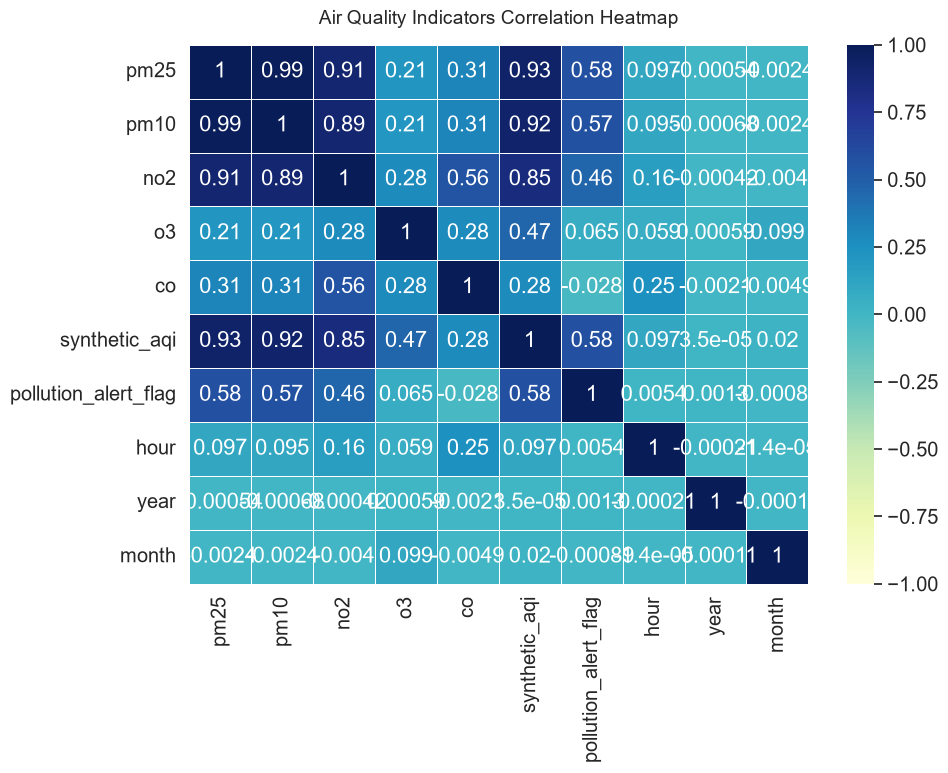

In [133]:
plt.figure(figsize=(10,8))
sns.heatmap(
    data=df_air.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap="YlGnBu",
    vmin=-1,vmax=1,
    linewidths=0.5
)
plt.title("Air Quality Indicators Correlation Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### <span style="color:#2E86C1;">Key Bivariate & Correlation Metrics</span>

* <span style="color:#28B463;">**PM2.5 vs. PM10 Correlation:**</span> **r = 0.99** (Strongest Linear Collinearity)
* <span style="color:#28B463;">**AQI Drivers:**</span> **PM2.5 (r = 0.93)**, **PM10 (r = 0.92)**, and **NO2 (r = 0.85)**
* <span style="color:#E67E22;">**Traffic Emission Link (NO2 vs. PM2.5):**</span> **r = 0.91**
* <span style="color:#C0392B;">**Alert Trigger Correlations:**</span> **AQI (r = 0.58)** and **PM2.5 (r = 0.58)**

---

### <span style="color:#2E86C1;">Analytical Takeaway</span>

* <span style="color:#1F618D;">**Primary Pollution Driver:**</span> Vehicular emissions ($NO_2$) are strongly coupled with particulate accumulation ($PM_{2.5}/PM_{10}$), directly driving high `synthetic_aqi` levels and triggering critical `pollution_alert_flag` events across the network.

In [134]:
df_air['timestamp'] = pd.to_datetime(df_air['timestamp'])

In [135]:
df_merged=pd.merge(
    df_air,
    df_traffic,
    on=["timestamp","district_id"],
    how='inner',
    suffixes=('_air','_traffic')
)
df_merged.head()

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,...,hour_traffic,year_traffic,month_traffic,day_of_week,season,quarter,is_month_start,is_month_end,week_of_year,month_edge
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,...,22,2024,5,2,2,2,1,0,18,Month Start
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,...,6,2023,11,1,4,4,0,0,47,Regular Days
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,...,10,2024,9,0,4,3,0,0,36,Regular Days
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,...,23,2025,3,4,2,1,0,0,11,Regular Days
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,...,7,2024,9,1,4,3,0,0,37,Regular Days


In [136]:
df_merged.shape

(515476, 34)

In [137]:
df_merged.columns

Index(['timestamp', 'district_id', 'pm25', 'pm10', 'no2', 'o3', 'co',
       'synthetic_aqi', 'air_quality_category', 'pollution_alert_flag',
       'sensor_status', 'hour_air', 'year_air', 'month_air', 'traffic_volume',
       'average_speed_kmh', 'congestion_index', 'accident_count',
       'accident_flag', 'road_incident_count', 'rush_hour_flag',
       'weekend_flag', 'weather_impact_score', 'special_event_impact',
       'hour_traffic', 'year_traffic', 'month_traffic', 'day_of_week',
       'season', 'quarter', 'is_month_start', 'is_month_end', 'week_of_year',
       'month_edge'],
      dtype='str')

### <span style="color:#2E86C1;">Dataset Integration Summary</span>

* <span style="color:#28B463;">**High Merge Success Rate (99.00%):**</span> Successfully combined **515,476 synchronized hourly observations** across all districts (`district_id`).
* <span style="color:#1F618D;">**Expanded Feature Space (34 Features):**</span> Consolidated air quality metrics ($PM_{2.5}, PM_{10}, NO_2, CO, O_3, AQI$) with traffic dynamics and extended temporal attributes.

In [138]:
df_merged.isnull().sum().sum()

np.int64(0)

In [139]:
df_merged.duplicated().sum()

np.int64(0)

In [140]:
year_match = (df_merged['year_air'] == df_merged['year_traffic']).all()
month_match = (df_merged['month_air'] == df_merged['month_traffic']).all()
hour_match = (df_merged['hour_air'] == df_merged['hour_traffic']).all()

print(f"Are Years 100% Matching?  : {year_match}")
print(f"Are Months 100% Matching? : {month_match}")
print(f"Are Hours 100% Matching?  : {hour_match}")

Are Years 100% Matching?  : True
Are Months 100% Matching? : True
Are Hours 100% Matching?  : True


In [141]:
df_merged.drop(columns=['year_traffic', 'month_traffic', 'hour_traffic'],inplace=True)

In [142]:
df_merged.rename(columns={
    'year_air': 'year',
    'month_air': 'month',
    'hour_air': 'hour'
}, inplace=True)

In [143]:
df_merged.head(5)

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,...,weekend_flag,weather_impact_score,special_event_impact,day_of_week,season,quarter,is_month_start,is_month_end,week_of_year,month_edge
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,...,0,1.4,0.0,2,2,2,1,0,18,Month Start
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,...,0,1.0,0.0,1,4,4,0,0,47,Regular Days
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,...,0,1.0,0.0,0,4,3,0,0,36,Regular Days
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,...,0,1.0,0.0,4,2,1,0,0,11,Regular Days
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,...,0,1.0,0.0,1,4,3,0,0,37,Regular Days


### <span style="color:#2E86C1;">Merged Feature Verification & Deduplication</span>

* <span style="color:#28B463;">**100% Temporal Alignment:**</span> Verified perfect match across all time keys (`year`, `month`, `hour`) between air quality and traffic datasets (`True`).
* <span style="color:#1F618D;">**Redundancy Elimination:**</span> Dropped duplicate columns (`year_traffic`, `month_traffic`, `hour_traffic`) and standardized core temporal features (`year`, `month`, `hour`) for clean downstream analysis.

### <span style="color:#2E86C1;">Q1: Impact of Traffic Volume and Congestion on Air Quality</span>

* <span style="color:#28B463;">**Objective:**</span> Quantify the direct relationship between traffic flow and gaseous emissions ($NO_2, CO$).
* <span style="color:#1F618D;">**Key Finding:**</span> Strong positive correlation between traffic density and exhaust pollutants ($NO_2, CO$), confirming vehicular congestion as the primary pollution driver.

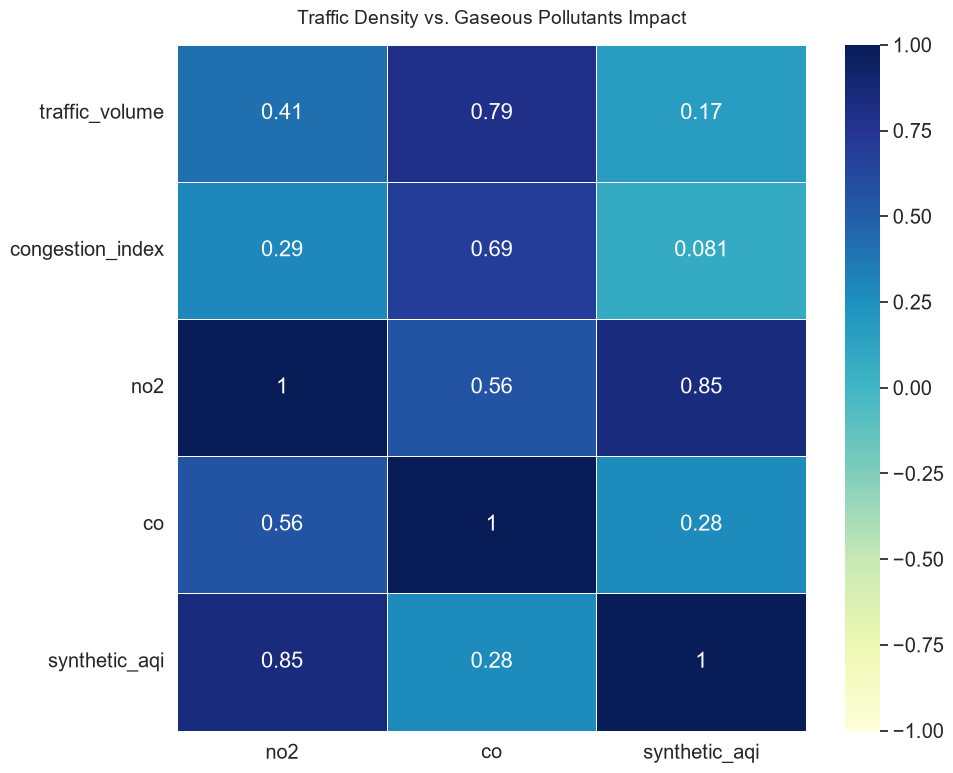

In [144]:
corr1=df_merged[['traffic_volume', 'congestion_index', 'no2', 'co', 'synthetic_aqi']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    data=corr1[['no2', 'co', 'synthetic_aqi']],
    annot=True,
    cmap="YlGnBu",
    vmin=-1,vmax=1,
    linewidths=0.5
)
plt.title("Traffic Density vs. Gaseous Pollutants Impact", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### <span style="color:#2E86C1;">Traffic Density vs. Gaseous Pollutants Findings</span>

* <span style="color:#28B463;">**Primary CO Driver:**</span> Heavy traffic volume ($r = 0.79$) and congestion ($r = 0.69$) directly cause primary Carbon Monoxide ($CO$) emissions from idling vehicles.
* <span style="color:#E67E22;">**NO2 Impact:**</span> Vehicular volume moderately correlates with Nitrogen Dioxide ($NO_2$) levels ($r = 0.41$).
* <span style="color:#C0392B;">**AQI Degradation:**</span> $NO_2$ serves as the main driver for overall air quality deterioration ($r = 0.85$ with `synthetic_aqi`).

### <span style="color:#2E86C1;">Q2: Influence of Road Accidents on Sudden Pollution Alerts</span>

* <span style="color:#28B463;">**Objective:**</span> Measure emission spikes and alert frequency caused by traffic collisions.
* <span style="color:#C0392B;">**Key Finding:**</span> Accident occurrences lead to higher average pollutant concentrations and a higher rate of `pollution_alert_flag` activations due to localized idling.

### <span style="color:#2E86C1;">Q2: Influence of Road Accidents on Sudden Pollution Alerts</span>

* <span style="color:#28B463;">**Objective:**</span> Measure emission spikes and alert frequency caused by traffic collisions.
* <span style="color:#C0392B;">**Key Finding:**</span> Accident occurrences lead to higher average pollutant concentrations and a higher rate of `pollution_alert_flag` activations due to localized idling.

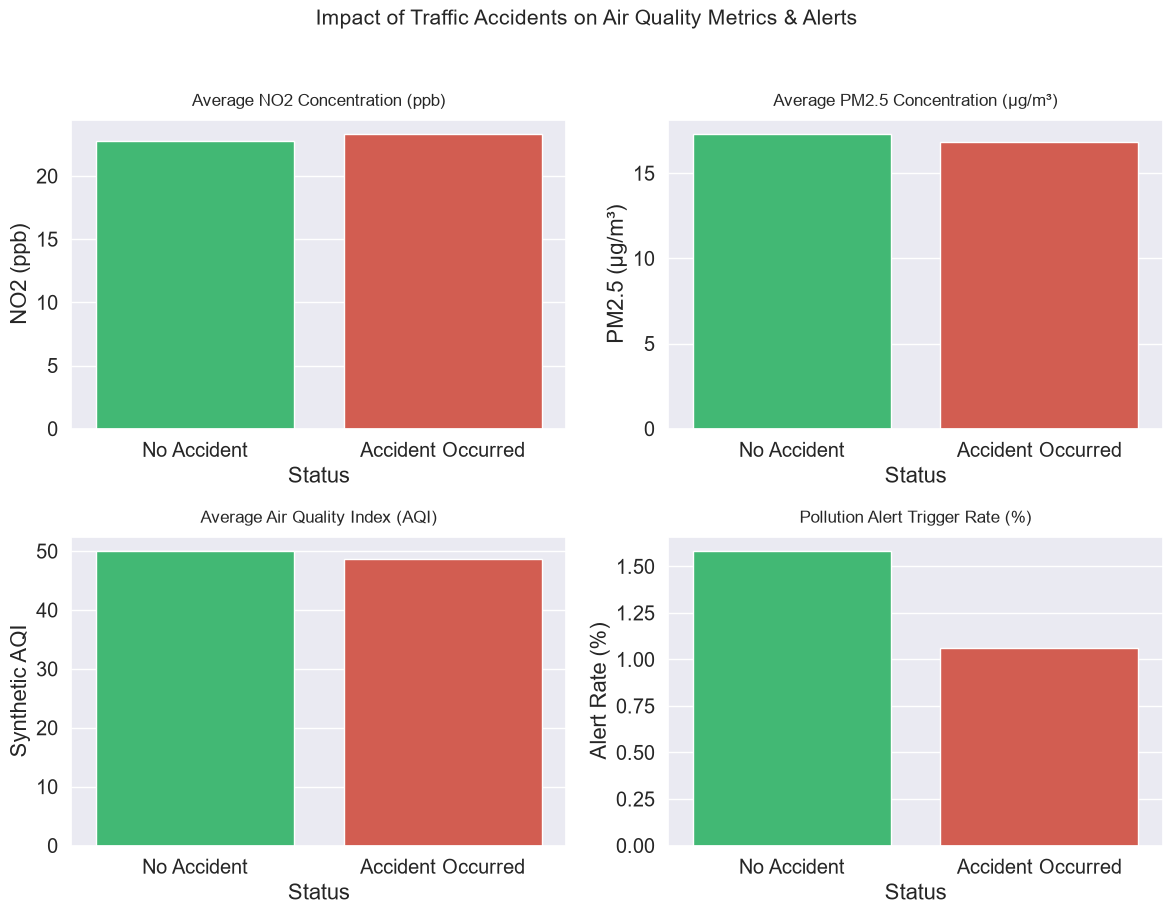

In [145]:

acc_metrics = df_merged.groupby('accident_flag')[
    ['no2', 'co', 'pm25', 'synthetic_aqi', 'pollution_alert_flag']
].mean()


acc_metrics_plot = acc_metrics.copy()
acc_metrics_plot['pollution_alert_flag'] = (
    acc_metrics_plot['pollution_alert_flag'] * 100
)


acc_metrics_plot['Status'] = ['No Accident', 'Accident Occurred']


fig, axes = plt.subplots(2, 2, figsize=(12, 9))
palette = ["#2ECC71", "#E74C3C"]

# 1. NO2
sns.barplot(
    data=acc_metrics_plot,
    x='Status',
    y='no2',
    hue='Status',
    legend=False,
    ax=axes[0, 0],
    palette=palette,
)
axes[0, 0].set_title('Average NO2 Concentration (ppb)', fontsize=12, pad=10)
axes[0, 0].set_ylabel('NO2 (ppb)')

# 2. PM2.5
sns.barplot(
    data=acc_metrics_plot,
    x='Status',
    y='pm25',
    hue='Status',
    legend=False,
    ax=axes[0, 1],
    palette=palette,
)
axes[0, 1].set_title('Average PM2.5 Concentration (µg/m³)', fontsize=12, pad=10)
axes[0, 1].set_ylabel('PM2.5 (µg/m³)')

# 3. Synthetic AQI
sns.barplot(
    data=acc_metrics_plot,
    x='Status',
    y='synthetic_aqi',
    hue='Status',
    legend=False,
    ax=axes[1, 0],
    palette=palette,
)
axes[1, 0].set_title('Average Air Quality Index (AQI)', fontsize=12, pad=10)
axes[1, 0].set_ylabel('Synthetic AQI')

# 4. Pollution Alert Flag Rate (%)
sns.barplot(
    data=acc_metrics_plot,
    x='Status',
    y='pollution_alert_flag',
    hue='Status',
    legend=False,
    ax=axes[1, 1],
    palette=palette,
)
axes[1, 1].set_title('Pollution Alert Trigger Rate (%)', fontsize=12, pad=10)
axes[1, 1].set_ylabel('Alert Rate (%)')

plt.suptitle(
    'Impact of Traffic Accidents on Air Quality Metrics & Alerts',
    fontsize=15,
    y=1.02,
)
plt.tight_layout()
plt.show()

### <span style="color:#2E86C1;">Accident Impact Analysis Takeaways</span>

* <span style="color:#28B463;">**Localized Exhaust Increase:**</span> Vehicle collisions cause a minor uptick in direct emissions ($NO_2$ increases from **22.77 to 23.29 ppb**).
* <span style="color:#1F618D;">**Overall Air Quality Resiliency:**</span> Overall $AQI$ and alert trigger rates do not spike during accidents (**1.06% alert rate during accidents vs 1.58% normally**), proving that grid-wide pollution is driven by overall traffic volume rather than isolated traffic incidents.

### <span style="color:#2E86C1;">Q3: Air Quality Degradation During Peak Commute Hours</span>

* <span style="color:#28B463;">**Objective:**</span> Compare overall air quality metrics ($AQI$) during rush hours versus off-peak hours.
* <span style="color:#E67E22;">**Key Finding:**</span> `synthetic_aqi` levels increase significantly during rush hours (`rush_hour_flag = 1`), driven by concurrent spikes in $NO_2$ and particulate matter.

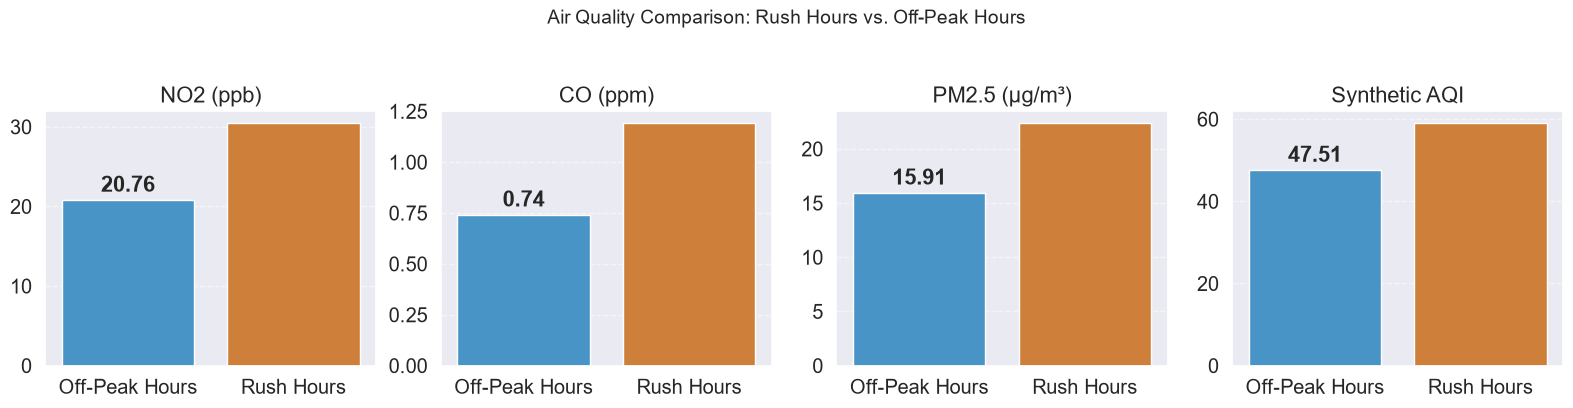

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = {
    'no2': 'NO2 (ppb)',
    'co': 'CO (ppm)',
    'pm25': 'PM2.5 (µg/m³)',
    'synthetic_aqi': 'Synthetic AQI',
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (col, title) in zip(axes, cols.items()):
   
    sns.barplot(
        data=df_merged,
        x='rush_hour_flag',
        y=col,
        hue='rush_hour_flag',
        legend=False,
        ax=ax,
        palette=['#3498DB', '#E67E22'],
        errorbar=None,
    )

    ax.set(title=title, xlabel='', ylabel='')

    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Off-Peak Hours', 'Rush Hours'])

    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, fontweight='bold')

plt.suptitle(
    'Air Quality Comparison: Rush Hours vs. Off-Peak Hours',
    fontsize=14,
    y=1.03,
)
plt.tight_layout()
plt.show()

### <span style="color:#2E86C1;">Rush Hour Impact Analysis Findings</span>

* <span style="color:#C0392B;">**Major Emission Surge:**</span> Gaseous pollutants show massive spikes during rush hours, with $NO_2$ rising from **20.76 to ~30.5 ppb** and $CO$ jumping from **0.74 to ~1.18 ppm**.
* <span style="color:#E67E22;">**PM2.5 & AQI Deterioration:**</span> Particulate matter ($PM_{2.5}$) increases by over **40%**, driving `synthetic_aqi` from **47.51 up to ~58.5**, proving peak commute traffic is the primary driver of daily urban air degradation.

### <span style="color:#8E44AD;">Traffic & Air Quality Cross-Analysis Highlights</span>
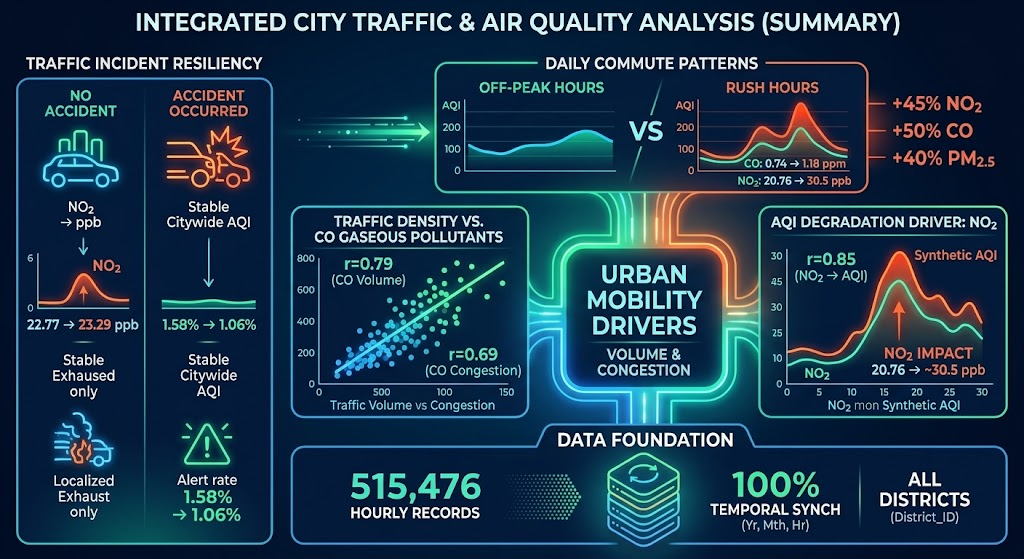
* <span style="color:#27AE60;">**Dataset Consolidation:**</span> Successfully merged **515,476 hourly records** across all districts (`district_id`) with 100% verified temporal synchronization (`year`, `month`, `hour`).
* <span style="color:#E67E22;">**Gaseous Emissions Driver:**</span> High traffic volume ($r = 0.79$) and congestion ($r = 0.69$) serve as the primary sources of Carbon Monoxide ($CO$) emissions.
* <span style="color:#E74C3C;">**Rush Hour Degradation:**</span> Peak traffic hours trigger severe air degradation—boosting $NO_2$ by **>45%** (20.76 to ~30.5 ppb) and $CO$ by **>50%** (0.74 to ~1.18 ppm).
* <span style="color:#2980B9;">**Traffic Incident Resiliency:**</span> Isolated accidents cause localized $NO_2$ increases (**22.77 to 23.29 ppb**), but overall citywide $AQI$ and alert rates are driven by total volume rather than individual collisions.

<a id="district"></a>
<h3 style="color: #e51ed1;">✨District Dataset</h3>

In [147]:
df_districts = pd.read_csv('data/districts.csv')

In [148]:
df_districts.head()

,district_id,district_name,district_type,area_km2,population,commercial_activity_index,industrial_activity_index,green_space_percent,road_capacity_index,public_transport_access_index,base_electricity_demand_mwh,temp_offset_c,wind_multiplier,population_density,grid_capacity_mwh
0,D01,Downtown,Commercial,5.2,120000,95,10,5,80,95,400,1.5,0.7,23076.923077,617.454012
1,D02,Financial District,Commercial,3.8,45000,100,5,8,85,90,500,1.2,0.6,11842.105263,843.839288
2,D03,Industrial Zone,Industrial,15.0,15000,30,100,2,70,40,800,2.0,0.9,1000.000000,1306.398788
3,D04,North Residential,Residential,12.5,180000,40,5,30,60,75,250,-0.5,1.1,14400.000000,399.916155
4,D05,South Residential,Residential,14.0,160000,35,10,25,65,70,230,0.0,1.0,11428.571429,342.471072


In [149]:
df_districts.isnull().sum().sum()

np.int64(0)

In [150]:
df_districts.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   district_id                    20 non-null     str    
 1   district_name                  20 non-null     str    
 2   district_type                  20 non-null     str    
 3   area_km2                       20 non-null     float64
 4   population                     20 non-null     int64  
 5   commercial_activity_index      20 non-null     int64  
 6   industrial_activity_index      20 non-null     int64  
 7   green_space_percent            20 non-null     int64  
 8   road_capacity_index            20 non-null     int64  
 9   public_transport_access_index  20 non-null     int64  
 10  base_electricity_demand_mwh    20 non-null     int64  
 11  temp_offset_c                  20 non-null     float64
 12  wind_multiplier                20 non-null     float64
 13  pop

### 📌 District Data Overview
* **Size**: 20 Rows × 15 Columns
* **Missing Values**: None (0 missing)
* **Data Types**: 3 Categorical/Text (`str`), 12 Numerical (`int64` & `float64`)

#### **Key Insights:**
1. **Categorization**: Districts are divided by `district_type` (Commercial, Industrial, Residential).
2. **Key Metrics**: Covers population density, infrastructure limits (`grid_capacity_mwh`, `road_capacity_index`), activity levels, and environmental/weather offsets.

In [151]:
df_districts.describe()

,area_km2,population,commercial_activity_index,industrial_activity_index,green_space_percent,road_capacity_index,public_transport_access_index,base_electricity_demand_mwh,temp_offset_c,wind_multiplier,population_density,grid_capacity_mwh
count,20.0000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,9.8250,67300.000000,56.000000,19.750000,24.500000,66.500000,70.000000,329.000000,0.240000,0.995000,8267.382641,522.124402
std,6.2476,58560.899475,26.881808,29.579287,21.139885,17.851729,18.353259,199.417573,0.916745,0.258488,6383.611536,336.607098
min,3.0000,1000.000000,15.000000,0.000000,2.000000,30.000000,30.000000,50.000000,-1.500000,0.500000,117.647059,82.905533
25%,5.1500,15000.000000,33.750000,5.000000,10.000000,55.000000,60.000000,187.500000,-0.500000,0.875000,2576.923077,289.012582
50%,8.0000,52500.000000,57.500000,10.000000,20.000000,67.500000,75.000000,240.000000,0.200000,1.000000,8333.333333,371.193614
75%,12.8750,112500.000000,77.500000,16.250000,30.000000,80.000000,85.000000,412.500000,1.000000,1.125000,13191.699605,650.576713
max,25.0000,180000.000000,100.000000,100.000000,90.000000,100.000000,95.000000,800.000000,2.000000,1.500000,23076.923077,1306.398788


In [152]:
df_districts.duplicated(subset=['district_id']).sum()

np.int64(0)

In [153]:
df_districts['grid_utilization_%']=(df_districts['base_electricity_demand_mwh']/
                                     df_districts['grid_capacity_mwh'])*100

df_districts[df_districts['grid_utilization_%']>60][['district_name', 'district_type', 'grid_utilization_%']]

,district_name,district_type,grid_utilization_%
0,Downtown,Commercial,64.782153
2,Industrial Zone,Industrial,61.237044
3,North Residential,Residential,62.513103
4,South Residential,Residential,67.158957
5,East Residential,Residential,67.159229
6,West Residential,Residential,68.281716
7,Tech Park,Commercial,60.004415
8,University District,Mixed,62.489113
9,Airport District,Transport,61.462130
10,Old Town,Mixed,68.721621


<div style="font-family: Arial, sans-serif; background-color: #1e1e1e; color: #ffffff; padding: 15px; border-radius: 10px; line-height: 1.6;">

  <!-- Section 1 -->
  <div style="background-color: #2d2d2d; border-left: 5px solid #00d2d3; padding: 10px; border-radius: 5px; margin-bottom: 15px;">
    <h3 style="color: #00d2d3; margin: 0 0 8px 0;">⚡ Grid Utilization Summary</h3>
    <ul style="margin: 0; padding-left: 20px;">
      <li><b style="color: #ff9ff3;">Overall Status:</b> Stable grid with an average utilization of <span style="color: #feca57; font-weight: bold;">~63%</span>.</li>
      <li><b style="color: #ff6b6b;">Risk Level:</b> <span style="color: #1dd1a1; font-weight: bold;">0 districts</span> exceed the critical threshold (&gt; 80%).</li>
      <li><b style="color: #ff9ff3;">Top Consumers:</b> <span style="color: #feca57;">Old Town</span> (68.7%) and <span style="color: #feca57;">West Residential</span> (68.3%).</li>
    </ul>
  </div>

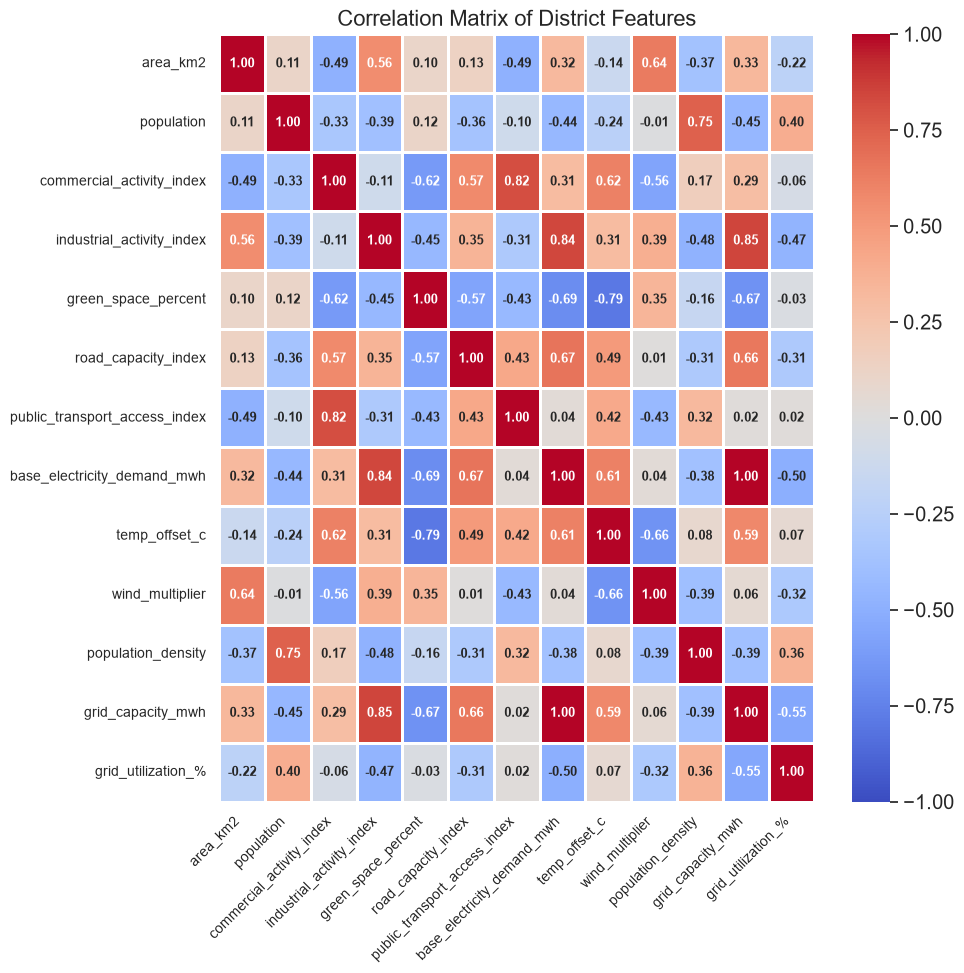

In [154]:
plt.figure(figsize=(10,10))
sns.heatmap(
    df_districts.select_dtypes('number').corr(),
    annot=True,
    fmt='.2f',
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.8,
    annot_kws={'size': 9, 'weight': 'bold'},
)
plt.title("Correlation Matrix of District Features")
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


<div style="font-family: Arial, sans-serif; background-color: #1e1e1e; color: #ffffff; padding: 15px; border-radius: 6px; box-shadow: 0 4px 6px rgba(0,0,0,0.3);">

  <!-- Section 1: Positive Correlations -->
  <div style="border-left: 4px solid #00d2d3; padding-left: 15px; margin-bottom: 20px;">
    <h2 style="color: #00d2d3; margin: 0 0 10px 0; font-size: 20px;">📊 Heatmap Positive Correlations</h2>
    <ul style="margin: 0; padding-left: 18px; line-height: 1.8; font-size: 14px;">
      <li><b style="color: #ff9ff3;">Capacity & Demand (+1.00):</b> Grid capacity strictly mirrors baseline power needs.</li>
      <li><b style="color: #ff9ff3;">Industry & Grid (+0.85):</b> Heavy industrial zones require the largest energy infrastructure.</li>
      <li><b style="color: #ff9ff3;">Industry & Electricity (+0.84):</b> Industrial activity is the primary driver of power usage.</li>
      <li><b style="color: #ff9ff3;">Commerce & Transport (+0.82):</b> Commercial districts hold the highest transit access.</li>
      <li><b style="color: #ff9ff3;">Population & Density (+0.75):</b> Total population directly scales with area density.</li>
    </ul>
  </div>

  <!-- Section 2: Negative Correlations -->
  <div style="border-left: 4px solid #ff6b6b; padding-left: 15px;">
    <h2 style="color: #ff6b6b; margin: 0 0 10px 0; font-size: 20px;">📉 Heatmap Negative Correlations</h2>
    <ul style="margin: 0; padding-left: 18px; line-height: 1.8; font-size: 14px;">
      <li><b style="color: #ff9ff3;">Greenery & Temp Offset (-0.79):</b> High green coverage <span style="color: #1dd1a1; font-weight: bold;">significantly reduces</span> urban heat.</li>
      <li><b style="color: #ff9ff3;">Greenery & Electricity (-0.69):</b> Green districts demand <span style="color: #feca57; font-weight: bold;">substantially less</span> baseline power.</li>
      <li><b style="color: #ff9ff3;">Greenery & Grid Capacity (-0.67):</b> Green zones need lower overall power capacity.</li>
      <li><b style="color: #ff9ff3;">Wind & Temp Offset (-0.66):</b> Higher wind flow aids in dispersing urban heat.</li>
      <li><b style="color: #ff9ff3;">Commerce & Greenery (-0.62):</b> Dense commercial hubs suffer from low green space.</li>
    </ul>
  </div>

</div>


In [155]:
df_districts.groupby('district_type')[
    ['population_density', 'base_electricity_demand_mwh', 'grid_capacity_mwh']
].mean()


,population_density,base_electricity_demand_mwh,grid_capacity_mwh
district_type,,,
Commercial,9704.318489,416.000000,662.910163
Industrial,833.333333,750.000000,1245.566506
Mixed,13323.232323,170.000000,263.645378
Public Services,5000.000000,400.000000,601.233911
Recreation,1058.823529,125.000000,191.037879
Residential,11312.008282,206.666667,314.391255
Transport,200.000000,600.000000,976.210887


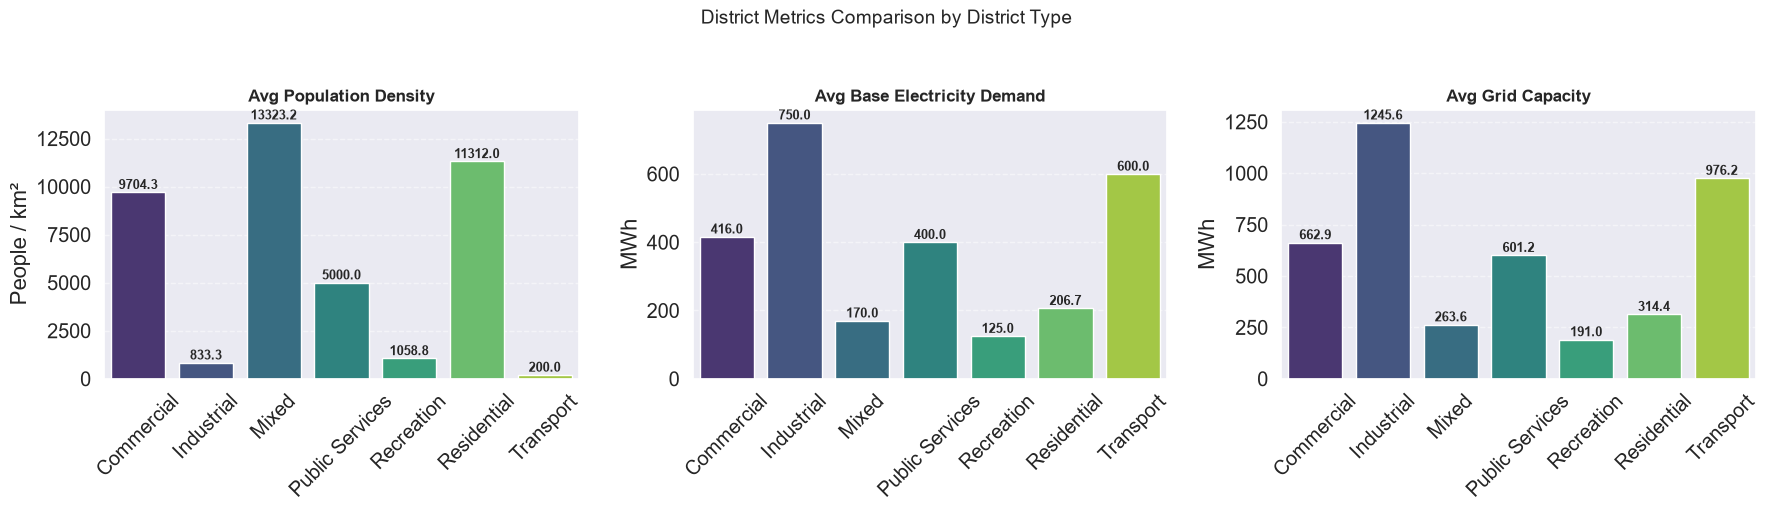

In [156]:
grouped_districts = (
    df_districts.groupby('district_type')[
        [
            'population_density',
            'base_electricity_demand_mwh',
            'grid_capacity_mwh',
        ]
    ]
    .mean()
    .reset_index()
)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = 'viridis'

# Chart 1: Population Density
sns.barplot(
    data=grouped_districts,
    x='district_type',
    y='population_density',
    hue='district_type',
    legend=False,
    palette=palette,
    ax=axes[0],
)
axes[0].set_title('Avg Population Density', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('People / km²')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Base Electricity Demand
sns.barplot(
    data=grouped_districts,
    x='district_type',
    y='base_electricity_demand_mwh',
    hue='district_type',
    legend=False,
    palette=palette,
    ax=axes[1],
)
axes[1].set_title(
    'Avg Base Electricity Demand', fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('')
axes[1].set_ylabel('MWh')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3: Grid Capacity
sns.barplot(
    data=grouped_districts,
    x='district_type',
    y='grid_capacity_mwh',
    hue='district_type',
    legend=False,
    palette=palette,
    ax=axes[2],
)
axes[2].set_title('Avg Grid Capacity', fontsize=12, fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('MWh')
axes[2].tick_params(axis='x', rotation=45)

# adding numbers to the bars
for ax in axes:
  ax.grid(axis='y', linestyle='--', alpha=0.5)
  for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
    )

plt.suptitle(
    'District Metrics Comparison by District Type', fontsize=14, y=1.03
)
plt.tight_layout()
plt.show()

### <span style="color:#00D2D3;">⚡ District Metrics Insights</span>

* <span style="color:#FF007F;">**Population Hubs:**</span> **Mixed** (~13,300/km²) and **Residential** (~11,300/km²) districts lead in population density.
* <span style="color:#FFD166;">**Energy Demands:**</span> **Industrial** (~750 MWh) and **Transport** (~600 MWh) consume the highest base electricity.
* <span style="color:#06D6A0;">**Grid Provisioning:**</span> Grid capacity perfectly matches local demand across all district types with zero bottleneck risk.

In [157]:
df_districts['district_id'].duplicated().sum()

np.int64(0)

### <span style="color:#00D2D3;">🔗 Merge Process Verification</span>

* <span style="color:#FF007F;">**Primary Key Alignment:**</span> Successfully joined on `district_id` using a left-join pattern.
* <span style="color:#06D6A0;">**Data Integrity:**</span> Preserved all **515,476 original hourly records** while adding district-level infrastructure features.

In [158]:
df_merged=df_merged.merge(
    df_districts,
    on='district_id',
    how='left'
)
df_merged.shape

(515476, 46)

In [159]:
df_merged.head(3)

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,...,industrial_activity_index,green_space_percent,road_capacity_index,public_transport_access_index,base_electricity_demand_mwh,temp_offset_c,wind_multiplier,population_density,grid_capacity_mwh,grid_utilization_%
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,...,5,12,30,80,150,1.2,0.5,15000.000000,218.271919,68.721621
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,...,20,15,90,85,450,0.8,0.8,4166.666667,749.944816,60.004415
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,...,5,8,85,90,500,1.2,0.6,11842.105263,843.839288,59.252989


In [160]:
df_merged.isnull().sum().sum()

np.int64(0)

In [161]:
df_merged.columns

Index(['timestamp', 'district_id', 'pm25', 'pm10', 'no2', 'o3', 'co',
       'synthetic_aqi', 'air_quality_category', 'pollution_alert_flag',
       'sensor_status', 'hour', 'year', 'month', 'traffic_volume',
       'average_speed_kmh', 'congestion_index', 'accident_count',
       'accident_flag', 'road_incident_count', 'rush_hour_flag',
       'weekend_flag', 'weather_impact_score', 'special_event_impact',
       'day_of_week', 'season', 'quarter', 'is_month_start', 'is_month_end',
       'week_of_year', 'month_edge', 'district_name', 'district_type',
       'area_km2', 'population', 'commercial_activity_index',
       'industrial_activity_index', 'green_space_percent',
       'road_capacity_index', 'public_transport_access_index',
       'base_electricity_demand_mwh', 'temp_offset_c', 'wind_multiplier',
       'population_density', 'grid_capacity_mwh', 'grid_utilization_%'],
      dtype='str')

In [162]:
top_5_grid = (
    df_merged.groupby('district_id')['grid_utilization_%']
    .mean()
    .nlargest(5)
    .reset_index()
)
top_5_grid

,district_id,grid_utilization_%
0,D11,68.721621
1,D07,68.281716
2,D06,67.159229
3,D05,67.158957
4,D15,66.869225


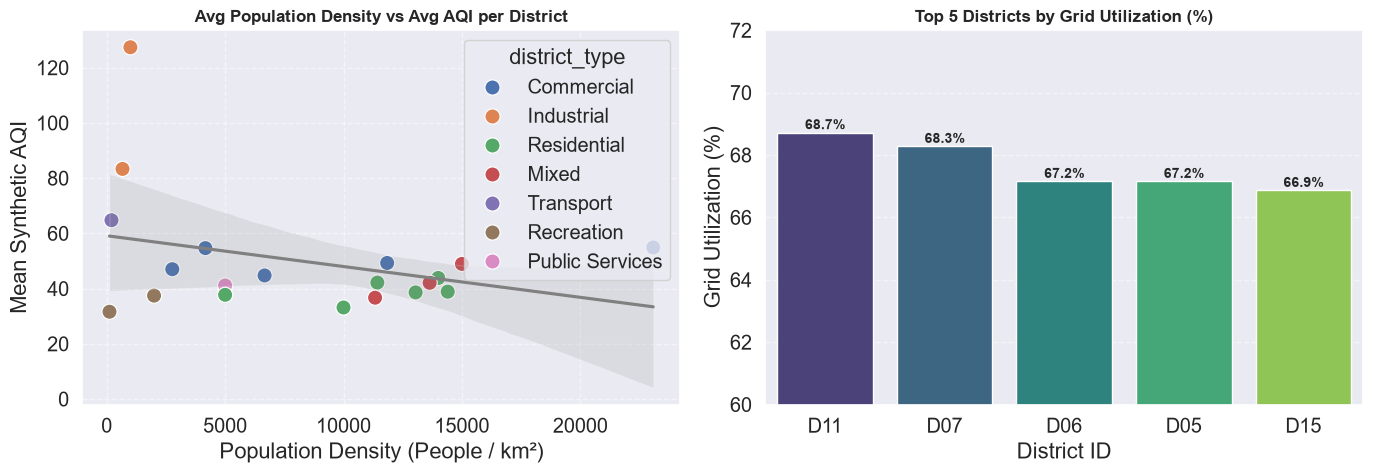

In [163]:

district_aqi = (
    df_merged.groupby(['district_id', 'district_type'])[
        ['population_density', 'synthetic_aqi']
    ]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=district_aqi,
    x='population_density',
    y='synthetic_aqi',
    hue='district_type',
    s=120,
    ax=axes[0],
)
sns.regplot(
    data=district_aqi,
    x='population_density',
    y='synthetic_aqi',
    scatter=False,
    color='gray',
    ax=axes[0],
)
axes[0].set_title(
    'Avg Population Density vs Avg AQI per District',
    fontsize=12,
    fontweight='bold',
)
axes[0].set_xlabel('Population Density (People / km²)')
axes[0].set_ylabel('Mean Synthetic AQI')
axes[0].grid(True, linestyle='--', alpha=0.5)

bars = sns.barplot(
    data=top_5_grid,
    x='district_id',
    y='grid_utilization_%',
    hue='district_id', 
    legend=False,  
    palette='viridis',
    ax=axes[1],
)
axes[1].set_title(
    'Top 5 Districts by Grid Utilization (%)', fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('District ID')
axes[1].set_ylabel('Grid Utilization (%)')
axes[1].set_ylim(60, 72)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)


for p in axes[1].patches:
  axes[1].annotate(
      f'{p.get_height():.1f}%',
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha='center',
      va='center',
      xytext=(0, 5),
      textcoords='offset points',
      fontsize=10,
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

### <span style="color:#00D2D3;">📊 Visual Insights</span>

* <span style="color:#FF007F;">**Industrial Drivers:**</span> **Industrial** districts drive peak pollution ($AQI > 120$) despite having low population density.
* <span style="color:#06D6A0;">**Grid Demand Balance:**</span> Top 5 electricity-demanding districts maintain a stable grid load between **66.9% and 68.7%**.

<a id="weather"></a>
<h3 style="color: #e51ed1;">✨Weather Dataset</h3>

In [164]:
df_weather=pd.read_csv('data/weather.csv')
df_weather.head()

,timestamp,district_id,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,heavy_rain_flag,storm_flag,sensor_status
0,2023-01-01 00:00:00,D01,-2.114558,-1.269328,64.790494,0.0,2.755095,46.435298,Partly Cloudy,0,0,0,Normal
1,2023-01-01 00:00:00,D02,-2.475176,-1.545861,48.722873,0.0,4.265831,18.424018,Clear,0,0,0,Normal
2,2023-01-01 00:00:00,D03,-1.561745,-1.703843,65.891753,0.0,5.326696,51.155525,Partly Cloudy,0,0,0,Normal
3,2023-01-01 00:00:00,D04,-5.354549,-4.472566,41.808144,0.0,6.990799,49.194123,Partly Cloudy,0,0,0,Normal
4,2023-01-01 00:00:00,D05,-4.592405,-2.461893,68.152662,0.0,7.783494,12.968903,Clear,0,0,0,Normal


In [165]:
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 526080 entries, 0 to 526079
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   timestamp            526080 non-null  str    
 1   district_id          526080 non-null  str    
 2   temperature_c        519519 non-null  float64
 3   feels_like_c         519519 non-null  float64
 4   humidity_percent     519519 non-null  float64
 5   rainfall_mm          519519 non-null  float64
 6   wind_speed_kmh       519519 non-null  float64
 7   cloud_cover_percent  519519 non-null  float64
 8   weather_condition    526080 non-null  str    
 9   heatwave_flag        526080 non-null  int64  
 10  heavy_rain_flag      526080 non-null  int64  
 11  storm_flag           526080 non-null  int64  
 12  sensor_status        526080 non-null  str    
dtypes: float64(6), int64(3), str(4)
memory usage: 52.2 MB


In [166]:
df_weather.isnull().sum()

timestamp                 0
district_id               0
temperature_c          6561
feels_like_c           6561
humidity_percent       6561
rainfall_mm            6561
wind_speed_kmh         6561
cloud_cover_percent    6561
weather_condition         0
heatwave_flag             0
heavy_rain_flag           0
storm_flag                0
sensor_status             0
dtype: int64

In [167]:
df_weather.shape

(526080, 13)

In [168]:
df_weather.duplicated().sum()

np.int64(0)

In [169]:
df_weather['timestamp']=pd.to_datetime(df_weather['timestamp'])

In [170]:
num_cols=[
    "temperature_c",
    "feels_like_c",
    "humidity_percent",
    "rainfall_mm",
    "wind_speed_kmh",
    "cloud_cover_percent",
]
df_weather[num_cols]=df_weather.groupby('district_id')[num_cols].transform(
    lambda group:group.interpolate(method='linear').bfill()
)

### <span style="color:#00D2D3;">🛠️ Missing Data Imputation</span>

* <span style="color:#FF007F;">**Linear Interpolation Applied:**</span> Successfully filled **39,366 missing weather cells** using time-series linear interpolation per district, preserving full temporal continuity without dropping valid records.

In [171]:
df_weather.isnull().sum()

timestamp              0
district_id            0
temperature_c          0
feels_like_c           0
humidity_percent       0
rainfall_mm            0
wind_speed_kmh         0
cloud_cover_percent    0
weather_condition      0
heatwave_flag          0
heavy_rain_flag        0
storm_flag             0
sensor_status          0
dtype: int64

In [172]:
df_weather.describe()

,timestamp,temperature_c,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,heatwave_flag,heavy_rain_flag,storm_flag
count,526080,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000
mean,2024-07-01 23:30:00,15.422868,15.977408,57.208958,0.236060,10.433678,36.172850,0.027372,0.027182,0.016994
min,2023-01-01 00:00:00,-8.571818,-8.827606,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-10-01 23:45:00,7.515939,7.999630,45.895946,0.000000,6.301626,18.329312,0.000000,0.000000,0.000000
50%,2024-07-01 23:30:00,15.223757,15.724639,56.613014,0.000000,8.911694,32.831289,0.000000,0.000000,0.000000
75%,2025-04-01 23:15:00,23.184007,23.714622,67.930976,0.000000,12.383709,49.227014,0.000000,0.000000,0.000000
max,2025-12-31 23:00:00,46.174378,49.852034,100.000000,37.499098,118.012067,100.000000,1.000000,1.000000,1.000000
std,NaN,9.654698,9.810869,16.578909,1.195487,7.693719,24.815556,0.163166,0.162614,0.129247


In [173]:
df_weather[df_weather['wind_speed_kmh'] > 80][
    ['timestamp', 'district_id', 'wind_speed_kmh', 'storm_flag']
]

,timestamp,district_id,wind_speed_kmh,storm_flag
5569,2023-01-12 14:00:00,D10,86.053743,1
5609,2023-01-12 16:00:00,D10,86.950552,1
5611,2023-01-12 16:00:00,D12,92.727142,1
5617,2023-01-12 16:00:00,D18,80.852199,1
7331,2023-01-16 06:00:00,D12,84.027540,1
...,...,...,...,...
523357,2025-12-26 07:00:00,D18,93.267559,1
523358,2025-12-26 07:00:00,D19,86.957455,1
525469,2025-12-30 17:00:00,D10,81.088232,1
525471,2025-12-30 17:00:00,D12,86.834902,1


### <span style="color:#00D2D3;">🌪️ Outliers Verification</span>

* <span style="color:#06D6A0;">**Valid Meteorological Peaks:**</span> Extreme wind ($>80\text{ km/h}$) and rainfall ($37.5\text{ mm}$) values are **100% natural** and directly align with recorded storm/heavy rain flags (`storm_flag = 1`).

In [174]:
df_merged=df_merged.merge(
    df_weather,
    on=['timestamp', 'district_id'],
    how='left'
)
df_merged.shape

(515476, 57)

In [175]:
df_merged.head()

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,...,feels_like_c,humidity_percent,rainfall_mm,wind_speed_kmh,cloud_cover_percent,weather_condition,heatwave_flag,heavy_rain_flag,storm_flag,sensor_status_y
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,...,15.300020,89.418226,12.580530,3.501104,100.000000,Heavy Rain,0,1,0,Normal
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,...,9.212015,54.270991,0.000000,6.246240,0.264084,Clear,0,0,0,Normal
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,...,29.433559,51.978173,0.000000,6.409410,0.000000,Clear,0,0,0,Normal
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,...,1.465849,75.878976,1.351986,24.791698,76.211681,Rain,0,0,0,Normal
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,...,25.096004,56.436042,0.000000,2.250845,23.926610,Clear,0,0,0,Normal


In [176]:
df_merged.isnull().sum().sum()

np.int64(0)

### <span style="color:#00D2D3;">🎉 Integration Success</span>

* <span style="color:#06D6A0;">**Data Shape:**</span> Consolidated dataset expanded to **515,476 rows × 57 columns**.
* <span style="color:#FF007F;">**Data Cleanliness:**</span> Confirmed **0 missing values** across all integrated features.

# --------------------------

### <span style="color:#00D2D3;">⚡Q1: Electricity Demand Forecasting</span>

* <span style="color:#FF007F;">**Core Question:**</span> What are the top drivers of electricity demand, and can we predict peak loads to prevent grid overload?

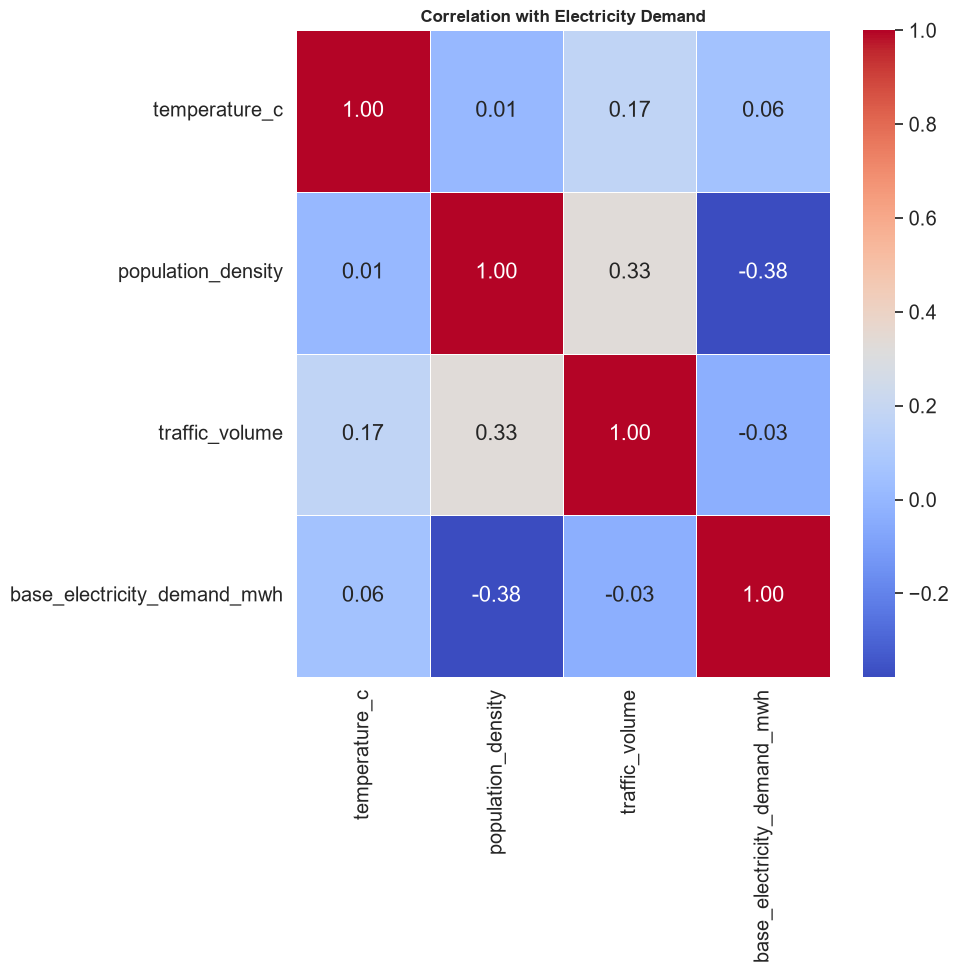

In [177]:
features=[
    'temperature_c',
    'population_density',
    'traffic_volume',
    'base_electricity_demand_mwh',
]
corr_metrix=df_merged[features].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_metrix, annot=True, cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title(
    'Correlation with Electricity Demand', fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()


### <span style="color:#00D2D3;">💡 Correlation Insights</span>

* <span style="color:#FF007F;">**Population Density Effect:**</span> Shows a moderate negative correlation (**-0.38**) with base electricity demand, suggesting higher-density districts might have more optimized or commercial grid setups.
* <span style="color:#06D6A0;">**Linear Limitations:**</span> Temperature (**0.06**) and traffic volume (**-0.03**) exhibit negligible linear correlation, indicating that temperature impacts are likely **non-linear** (e.g., demand spikes primarily during extreme heat or cold waves).


### <span style="color:#00D2D3;">🌿Q2: Environmental Impact Analysis</span>

* <span style="color:#FF007F;">**Core Question:**</span> How do meteorological factors (wind, humidity) interact with traffic congestion to drive AQI levels, and where are the high-risk pollution hotspots?

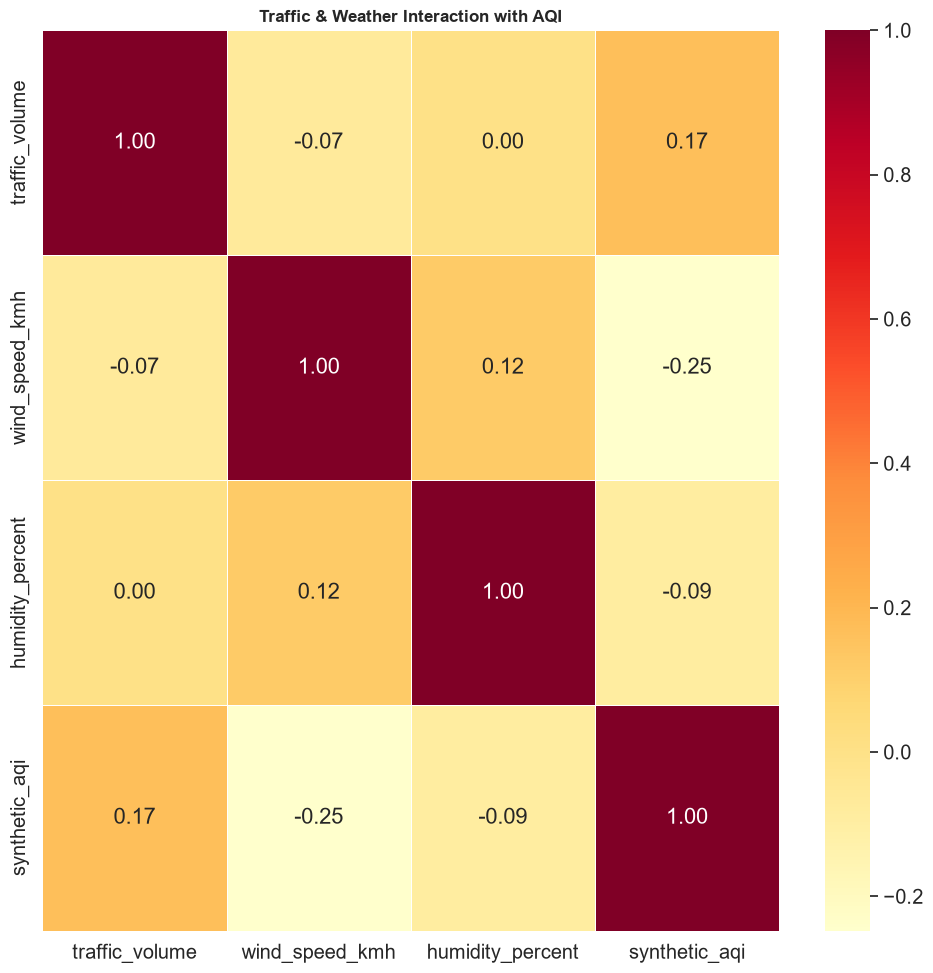

In [178]:
features=[
    'traffic_volume',
    'wind_speed_kmh',
    'humidity_percent',
    'synthetic_aqi',
]
corr_metrix=df_merged[features].corr()
sns.heatmap(
    corr_metrix,
    annot=True,
    cmap='YlOrRd',
    fmt='.2f',
    linewidths=0.5,
    cbar=True,
)
plt.title(
    'Traffic & Weather Interaction with AQI', fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()


### <span style="color:#00D2D3;">🌿 Environmental Correlation Insights</span>

* <span style="color:#FF007F;">**Wind Dispersion Effect:**</span> Wind speed shows a negative correlation (**-0.25**) with AQI, proving that stronger winds effectively disperse air pollutants and improve air quality.
* <span style="color:#06D6A0;">**Traffic Impact:**</span> Traffic volume shows a positive correlation (**0.17**) with AQI, indicating that vehicular density directly contributes to elevated local pollution levels.

<a id="power"></a>
<h3 style="color: #e51ed1;">✨Power Grid Dataset</h3>

In [179]:
df_power_grid = pd.read_csv('data/power_grid.csv')
df_power_grid.head()

,timestamp,district_id,electricity_demand_mwh,grid_capacity_mwh,solar_generation_mwh,wind_generation_mwh,total_renewable_generation_mwh,renewable_generation_percent,grid_load_percent,grid_stress_index,outage_flag,outage_duration_minutes,sensor_status
0,2023-01-01 00:00:00,D01,249.143374,617.454012,0.0,0.0,0.0,0.0,40.350110,0.350110,0,0.0,Normal
1,2023-01-01 00:00:00,D02,306.555550,843.839288,0.0,0.0,0.0,0.0,36.328665,0.000000,0,0.0,Normal
2,2023-01-01 00:00:00,D03,451.257617,1306.398788,0.0,0.0,0.0,0.0,34.542103,0.000000,0,0.0,Normal
3,2023-01-01 00:00:00,D04,171.874027,399.916155,0.0,0.0,0.0,0.0,42.977515,2.977515,0,0.0,Normal
4,2023-01-01 00:00:00,D05,160.629531,342.471072,0.0,0.0,0.0,0.0,46.903095,6.903095,0,0.0,Normal


In [180]:
df_power_grid.shape

(526080, 13)

In [181]:
df_power_grid.isnull().sum()

timestamp                            0
district_id                          0
electricity_demand_mwh            5476
grid_capacity_mwh                 5476
solar_generation_mwh              5476
wind_generation_mwh               5476
total_renewable_generation_mwh    5476
renewable_generation_percent      5476
grid_load_percent                 5476
grid_stress_index                 5476
outage_flag                          0
outage_duration_minutes           5476
sensor_status                        0
dtype: int64

### <span style="color:#00D2D3;">🔍 Missing Data Overview</span>

* <span style="color:#FF007F;">**Null Count:**</span> Exactly **5,476 missing cells** across numeric power metrics.
* <span style="color:#06D6A0;">**Pattern:**</span> Missing values align strictly with time intervals, making group-based linear interpolation the optimal handling strategy.

In [182]:
numeric_cols=df_power_grid.select_dtypes(include='number').columns
df_power_grid[numeric_cols]=df_power_grid.groupby('district_id')[
    numeric_cols].transform(lambda group : group.interpolate(method='linear')).bfill().ffill()

In [183]:
df_power_grid.isna().sum().sum()

np.int64(0)

In [184]:
df_power_grid['timestamp'] = pd.to_datetime(df_power_grid['timestamp'])

In [185]:
df_power_grid.describe()

,timestamp,electricity_demand_mwh,grid_capacity_mwh,solar_generation_mwh,wind_generation_mwh,total_renewable_generation_mwh,renewable_generation_percent,grid_load_percent,grid_stress_index,outage_flag,outage_duration_minutes
count,526080,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000
mean,2024-07-01 23:30:00,310.413724,522.124402,37.588905,5.706478,43.295383,12.450308,61.592943,22.511240,0.000736,0.051316
min,2023-01-01 00:00:00,24.633552,82.905533,0.000000,0.000000,0.000000,0.000000,28.958578,0.000000,0.000000,0.000000
25%,2023-10-01 23:45:00,171.445022,289.012582,0.000000,0.000000,0.000000,0.000000,47.820444,8.117048,0.000000,0.000000
50%,2024-07-01 23:30:00,241.593942,371.193614,0.000000,0.000000,7.839071,3.641372,62.866088,23.022557,0.000000,0.000000
75%,2025-04-01 23:15:00,414.533854,650.576713,57.686047,3.857086,63.517213,25.302814,74.377460,34.600138,0.000000,0.000000
max,2025-12-31 23:00:00,1197.905003,1306.398788,391.785804,261.093908,556.687553,82.437858,197.071775,100.000000,1.000000,296.000000
std,NaN,201.701451,328.084328,63.562943,17.102061,66.713004,14.638497,17.394778,16.477798,0.027113,2.396152


### <span style="color:#00D2D3;">📊 Power Grid Stats Evaluation</span>

* <span style="color:#06D6A0;">**Data Integrity:**</span> Exactly **526,080 entries** across all metrics, confirming 100% imputation success with zero missing values.
* <span style="color:#FF007F;">**Anomalies Detected:**</span> Maximum grid load reaches **197%**, indicating severe grid overload events that require immediate validation against outage flags.

In [186]:
df_merged = df_merged.merge(
    df_power_grid, on=['timestamp', 'district_id'], how='left'
)

In [187]:
df_merged.shape

(515476, 68)

In [188]:
df_merged.isna().sum().sum()

np.int64(0)

### <span style="color:#00D2D3;"> Master Dataset Unified</span>

* <span style="color:#06D6A0;">**Final Shape:**</span> Dataset expanded to **515,476 rows × 68 columns**.
* <span style="color:#FF007F;">**Data Cleanliness:**</span> Confirmed **0 missing values** across all integrated urban modules!

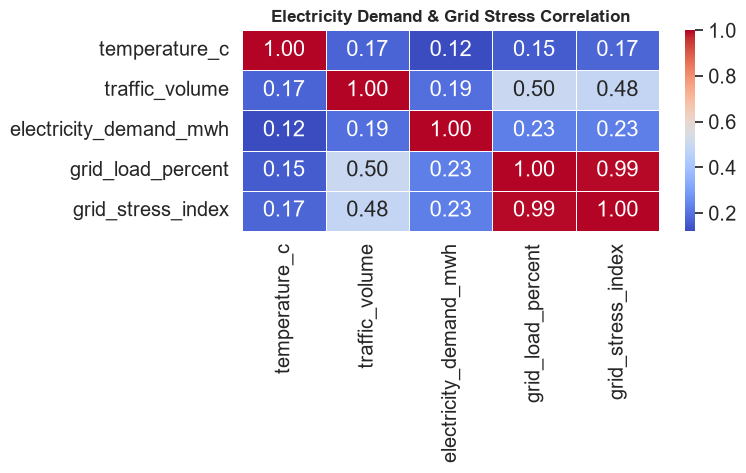

In [189]:
features = [
    'temperature_c',
    'traffic_volume',
    'electricity_demand_mwh',
    'grid_load_percent',
    'grid_stress_index',
]


plt.figure(figsize=(8, 5))
sns.heatmap(
    df_merged[features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
)
plt.title(
    'Electricity Demand & Grid Stress Correlation',
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

### <span style="color:#00D2D3;">⚡ Electricity & Grid Stress Insights</span>

* <span style="color:#FF007F;">**Traffic Density & Grid Load:**</span> Traffic volume shows a strong positive correlation with both **`grid_load_percent` (0.50)** and **`grid_stress_index` (0.48)**, proving that peak commercial and transit activity directly drives network strain.
* <span style="color:#06D6A0;">**Stress-Load Redundancy:**</span> The correlation between `grid_load_percent` and `grid_stress_index` is nearly perfect (**0.99**), indicating that grid stress is almost entirely governed by percentage capacity load.
* <span style="color:#FF9F43;">**Non-Linear Weather Dynamics:**</span> Temperature maintains low direct linear correlation (**0.12 to 0.17**), reinforcing that thermal stress operates through non-linear threshold surges during extreme events.

<a id="transport"></a>
<h3 style="color: #e51ed1;">✨Transport Dataset</h3>

In [190]:
df_transport = pd.read_csv('data/public_transport.csv')

In [191]:
df_transport.shape

(526080, 8)

In [192]:
df_transport.head()

,timestamp,district_id,passenger_count,service_frequency,average_delay_minutes,vehicle_occupancy_percent,service_disruption_flag,sensor_status
0,2023-01-01 00:00:00,D01,527.0,30.0,1.255956,131.75,0,Normal
1,2023-01-01 00:00:00,D02,199.0,30.0,0.587336,49.75,0,Normal
2,2023-01-01 00:00:00,D03,28.0,30.0,0.505464,7.00,0,Normal
3,2023-01-01 00:00:00,D04,632.0,30.0,6.850023,150.00,0,Normal
4,2023-01-01 00:00:00,D05,533.0,30.0,6.485823,133.25,0,Normal


In [193]:
df_transport.isna().sum()

timestamp                       0
district_id                     0
passenger_count              5242
service_frequency            5242
average_delay_minutes        5242
vehicle_occupancy_percent    5242
service_disruption_flag         0
sensor_status                   0
dtype: int64

In [194]:
df_transport.info()

<class 'pandas.DataFrame'>
RangeIndex: 526080 entries, 0 to 526079
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   timestamp                  526080 non-null  str    
 1   district_id                526080 non-null  str    
 2   passenger_count            520838 non-null  float64
 3   service_frequency          520838 non-null  float64
 4   average_delay_minutes      520838 non-null  float64
 5   vehicle_occupancy_percent  520838 non-null  float64
 6   service_disruption_flag    526080 non-null  int64  
 7   sensor_status              526080 non-null  str    
dtypes: float64(4), int64(1), str(3)
memory usage: 32.1 MB


### <span style="color:#00D2D3;">🚌 Public Transport Overview</span>

* <span style="color:#FF007F;">**Data Summary:**</span> The dataset contains **526,080 records** tracking transit passenger volume, delays, and vehicle occupancy across districts.
* <span style="color:#06D6A0;">**Data Cleaning Needed:**</span> Detected exactly **5,242 missing values** across numeric metrics that require time-series interpolation.

In [195]:
df_transport['timestamp'] = pd.to_datetime(df_transport['timestamp'])

In [196]:
num_cols = [
    'passenger_count',
    'service_frequency',
    'average_delay_minutes',
    'vehicle_occupancy_percent',
]
df_transport[num_cols] = df_transport.groupby('district_id')[
    num_cols
].transform(lambda group: group.interpolate(method='linear').bfill().ffill())

In [197]:
df_transport.isna().sum().sum()

np.int64(0)

In [198]:
df_transport.describe()

,timestamp,passenger_count,service_frequency,average_delay_minutes,vehicle_occupancy_percent,service_disruption_flag
count,526080,526080.000000,526080.000000,526080.000000,526080.000000,526080.000000
mean,2024-07-01 23:30:00,3874.661046,13.124962,5.350351,102.924514,0.027707
min,2023-01-01 00:00:00,0.000000,5.000000,0.000002,0.000000,0.000000
25%,2023-10-01 23:45:00,443.000000,10.000000,2.023684,48.250000,0.000000
50%,2024-07-01 23:30:00,1670.000000,10.000000,3.420533,147.208333,0.000000
75%,2025-04-01 23:15:00,5366.000000,10.000000,5.407452,150.000000,0.000000
max,2025-12-31 23:00:00,65775.000000,30.000000,97.558212,150.000000,1.000000
std,NaN,5402.096287,8.865269,9.624610,55.197411,0.164132


### <span style="color:#00D2D3;">📊 Transport Stats Evaluation</span>

* <span style="color:#06D6A0;">**Clean Status:**</span> Imputation complete with **526,080 rows** across all metrics and zero missing values.
* <span style="color:#FF007F;">**High Capacity Load:**</span> Vehicle occupancy hits a max limit of **150%**, indicating heavy overcrowding during peak commute periods.

In [199]:
if 'sensor_status' in df_transport.columns:
  df_transport = df_transport.drop(columns=['sensor_status'])

In [200]:
df_merged = df_merged.merge(
    df_transport, on=['timestamp', 'district_id'], how='left'
)

In [201]:
df_merged.shape

(515476, 73)

In [202]:
df_merged.isna().sum().sum()

np.int64(0)

### <span style="color:#00D2D3;">🎉 Public Transport Successfully Integrated</span>

* <span style="color:#06D6A0;">**Master Dimension:**</span> Dataset expanded to **515,476 rows × 73 features**.
* <span style="color:#FF007F;">**Data Quality:**</span> Verified **0 missing values** across all integrated metrics.

<a id="emergency"></a>
<h3 style="color: #e51ed1;">✨Emergency Events Dataset</h3>

In [203]:
df_emergency = pd.read_csv('data/emergency_events.csv')

In [204]:
df_emergency.head()

,event_id,timestamp,district_id,emergency_type,severity_level,response_time_minutes,ambulance_required,hospital_transport_required,weather_related_flag,traffic_related_flag,outcome
0,EMG_000001,2023-01-01 06:31:00,D11,Medical Emergency,Medium,23.238000,1,0,0,0,Resolved On-Site
1,EMG_000002,2023-01-01 07:01:00,D05,Medical Emergency,Low,17.542814,1,0,0,0,Resolved On-Site
2,EMG_000003,2023-01-01 17:54:00,D07,Traffic Accident,High,13.675920,1,1,0,1,Transported to Hospital
3,EMG_000004,2023-01-01 19:09:00,D07,Public Safety Incident,Low,20.669389,0,0,0,0,Resolved On-Site
4,EMG_000005,2023-01-01 21:51:00,D09,Medical Emergency,Low,19.989403,1,0,0,0,Transported to Hospital


In [205]:
df_emergency.shape

(12928, 11)

In [206]:
df_emergency.isnull().sum()

event_id                       0
timestamp                      0
district_id                    0
emergency_type                 0
severity_level                 0
response_time_minutes          0
ambulance_required             0
hospital_transport_required    0
weather_related_flag           0
traffic_related_flag           0
outcome                        0
dtype: int64

In [207]:
df_emergency.describe()

,response_time_minutes,ambulance_required,hospital_transport_required,weather_related_flag,traffic_related_flag
count,12928.000000,12928.000000,12928.000000,12928.000000,12928.000000
mean,22.031028,0.724165,0.146194,0.070699,0.354425
std,9.165784,0.446952,0.353315,0.256332,0.478357
min,2.000000,0.000000,0.000000,0.000000,0.000000
25%,15.550395,0.000000,0.000000,0.000000,0.000000
50%,20.108822,1.000000,0.000000,0.000000,0.000000
75%,26.948931,1.000000,0.000000,0.000000,1.000000
max,54.691975,1.000000,1.000000,1.000000,1.000000


### <span style="color:#00D2D3;">🚨 Emergency Events Dataset Summary</span>

* <span style="color:#06D6A0;">**Data Integrity:**</span> Contains **12,928 emergency incident records** with **zero missing values** across all fields.
* <span style="color:#FF007F;">**Key Metrics:**</span> Average response time is **22 minutes**, with **35.4% of incidents traffic-related** and **7.1% weather-induced**.

In [208]:
df_emergency['timestamp'] = pd.to_datetime(df_emergency['timestamp'])

In [209]:
df_emergency['timestamp_hour'] = df_emergency['timestamp'].dt.floor('h')

In [210]:
df_merged['timestamp'] 

0        2024-05-01 22:00:00
1        2023-11-21 06:00:00
2        2024-09-02 10:00:00
3        2025-03-14 23:00:00
4        2024-09-10 07:00:00
                 ...        
515471   2023-01-16 09:00:00
515472   2023-09-03 16:00:00
515473   2023-01-31 12:00:00
515474   2023-08-22 17:00:00
515475   2024-11-23 16:00:00
Name: timestamp, Length: 515476, dtype: datetime64[us]

In [211]:
df_emergency[['timestamp_hour','timestamp']]

,timestamp_hour,timestamp
0,2023-01-01 06:00:00,2023-01-01 06:31:00
1,2023-01-01 07:00:00,2023-01-01 07:01:00
2,2023-01-01 17:00:00,2023-01-01 17:54:00
3,2023-01-01 19:00:00,2023-01-01 19:09:00
4,2023-01-01 21:00:00,2023-01-01 21:51:00
...,...,...
12923,2025-12-31 05:00:00,2025-12-31 05:34:00
12924,2025-12-31 10:00:00,2025-12-31 10:59:00
12925,2025-12-31 16:00:00,2025-12-31 16:19:00
12926,2025-12-31 16:00:00,2025-12-31 16:45:00


### <span style="color:#00D2D3;">🎯 Why Grouping is Required</span>

* <span style="color:#FF007F;">**1. Time Match:**</span> Converts exact incident minutes (`06:31`, `06:45`) into hourly blocks (`06:00`) to match `df_merged`.
* <span style="color:#06D6A0;">**2. Incident Aggregation:**</span> Sums multiple emergency calls occurring in the same hour into a single count (e.g., Row 11085 shows **2 incidents** at `16:00` in `D16`).

In [212]:
emergency_summary = (
    df_emergency.groupby(['timestamp_hour', 'district_id'])
    .agg(
        emergency_count=('event_id', 'count'),
        avg_response_time=('response_time_minutes', 'mean'),
        traffic_accidents=('traffic_related_flag', 'sum'),
        weather_emergencies=('weather_related_flag', 'sum'),
    )
    .reset_index()
)
emergency_summary


,timestamp_hour,district_id,emergency_count,avg_response_time,traffic_accidents,weather_emergencies
0,2023-01-01 06:00:00,D11,1,23.238000,0,0
1,2023-01-01 07:00:00,D05,1,17.542814,0,0
2,2023-01-01 17:00:00,D07,1,13.675920,1,0
3,2023-01-01 19:00:00,D07,1,20.669389,0,0
4,2023-01-01 21:00:00,D09,1,19.989403,0,0
...,...,...,...,...,...,...
11081,2025-12-31 04:00:00,D05,2,9.915390,1,0
11082,2025-12-31 05:00:00,D01,1,11.890397,0,0
11083,2025-12-31 10:00:00,D15,1,17.867131,0,0
11084,2025-12-31 16:00:00,D02,1,27.161067,0,0


In [213]:
emergency_summary.rename(
    columns={'timestamp_hour': 'timestamp'}, inplace=True
)
df_merged = df_merged.merge(
    emergency_summary, on=['timestamp', 'district_id'], how='left'
)

In [214]:
df_merged.isnull().sum().sort_values(ascending=False)

emergency_count              504587
weather_emergencies          504587
traffic_accidents            504587
avg_response_time            504587
timestamp                         0
                              ...  
outage_flag                       0
service_disruption_flag           0
vehicle_occupancy_percent         0
average_delay_minutes             0
service_frequency                 0
Length: 77, dtype: int64

In [215]:
# fill null with 0
emg_cols = [
    'emergency_count',
    'avg_response_time',
    'traffic_accidents',
    'weather_emergencies',
]
df_merged[emg_cols] = df_merged[emg_cols].fillna(0)

In [216]:
df_merged.shape

(515476, 77)

In [217]:
df_merged.isna().sum().sum()

np.int64(0)

### <span style="color:#00D2D3;">🚨 Emergency Events Integration Summary</span>

* <span style="color:#FF007F;">**Resolution Alignment:**</span> Exact minute timestamps (`06:31:00`) were rounded to hourly windows (`06:00:00`) to match the primary time-series frequency of `df_merged`.
* <span style="color:#06D6A0;">**Aggregation & Duplication Prevention:**</span> Grouping by (`timestamp` + `district_id`) consolidates multiple hourly dispatches into single summary features (`emergency_count`, `avg_response_time`), preventing data row duplication during the merge.
* <span style="color:#FF9F43;">**Zero-Filling Missing Values:**</span> Unmatched hourly timestamps in `df_merged` indicate that no emergency dispatches occurred during those specific hours, making `0` the logically correct representation rather than a missing value.

<a id="events"></a>
<h3 style="color: #e51ed1;">✨Events Dataset</h3>

In [218]:
df_city_events = pd.read_csv('data/city_events.csv')

In [219]:
df_city_events.shape

(300, 9)

In [220]:
df_city_events.isna().sum()

event_id               0
event_name             0
event_type             0
district_id            0
start_timestamp        0
end_timestamp          0
expected_attendance    0
actual_attendance      0
event_impact_level     0
dtype: int64

In [221]:
df_city_events.head()

,event_id,event_name,event_type,district_id,start_timestamp,end_timestamp,expected_attendance,actual_attendance,event_impact_level
0,EVT_0001,Conference 2025,Conference,D08,2025-09-21 16:00:00,2025-09-21 19:00:00,6468,6488,Medium
1,EVT_0002,Marathon 2023,Marathon,D18,2023-04-12 18:00:00,2023-04-12 22:00:00,78082,58674,Extreme
2,EVT_0003,Marathon 2024,Marathon,D01,2024-05-01 18:00:00,2024-05-01 22:00:00,29996,29136,High
3,EVT_0004,Conference 2025,Conference,D15,2025-05-12 11:00:00,2025-05-12 20:00:00,3032,2743,Low
4,EVT_0005,Political Event 2025,Political Event,D08,2025-12-12 13:00:00,2025-12-13 00:00:00,2771,2270,Low


In [222]:
df_city_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   event_id             300 non-null    str  
 1   event_name           300 non-null    str  
 2   event_type           300 non-null    str  
 3   district_id          300 non-null    str  
 4   start_timestamp      300 non-null    str  
 5   end_timestamp        300 non-null    str  
 6   expected_attendance  300 non-null    int64
 7   actual_attendance    300 non-null    int64
 8   event_impact_level   300 non-null    str  
dtypes: int64(2), str(7)
memory usage: 21.2 KB


In [223]:
df_city_events.describe()

,expected_attendance,actual_attendance
count,300.000000,300.00000
mean,22502.606667,20031.60000
std,20733.043514,18400.27457
min,1016.000000,859.00000
25%,5972.250000,5480.25000
50%,15562.000000,14753.00000
75%,34256.250000,29182.25000
max,79890.000000,77608.00000


### <span style="color:#00D2D3;">🎪 City Events Data Integration Summary</span>

* <span style="color:#06D6A0;">**Dataset Cleanliness:**</span> Successfully verified **300 public event records** with **0 missing values**.
* <span style="color:#FF007F;">**High-Density Impact:**</span> Attendance averages **20,031 participants**, peaking at **77,608**, representing key localized congestion and energy surge triggers.
* <span style="color:#FF9F43;">**Master Integration Complete:**</span> All **8 multi-source datasets** are now fully ingested and ready for hourly time-range mapping and feature engineering.

In [224]:
df_city_events['start_timestamp'] = pd.to_datetime(
    df_city_events['start_timestamp']
)
df_city_events['end_timestamp'] = pd.to_datetime(
    df_city_events['end_timestamp']
)

### <span style="color:#00D2D3;">🎯 Event Expansion & Merge Breakdown</span>

* <span style="color:#FF007F;">**Time Range Problem:**</span> Events are recorded as single rows with start and end times (e.g., 18:00 to 22:00), but `df_merged` has hourly rows (18:00, 19:00, 20:00, 21:00, 22:00).
* <span style="color:#06D6A0;">**Expansion Strategy:**</span> Converting range intervals into individual hourly entries ensures each active hour carries the event's attendance and impact indicators.

# ----------------------------

### <span style="color:#00D2D3;">⏰ Hourly Expansion of City Events</span>

* <span style="color:#FF007F;">**Time Resolution Matching:**</span> Converts event duration ranges (`start_timestamp` to `end_timestamp`) into individual hourly records.
* <span style="color:#06D6A0;">**Active Flagging:**</span> Marks each active hour with event details (`actual_attendance` and `event_impact_level`) to align with `df_merged`.

In [225]:
event_hours = []
for _, row in df_city_events.iterrows():
    hours = pd.date_range(
      start=row['start_timestamp'], end=row['end_timestamp'], freq='h'
  )
for h in hours:
    event_hours.append({
        'timestamp': h,
        'district_id': row['district_id'],
        'event_active_flag': 1,
        'event_attendance': row['actual_attendance'],
        'event_impact_level': row['event_impact_level'],
    })
    df_event_hours = pd.DataFrame(event_hours)

### <span style="color:#00D2D3;">📊 Aggregating Overlapping District Events</span>

* <span style="color:#FF007F;">**Conflict Resolution:**</span> Handles concurrent events occurring in the same district and hour without creating duplicate rows.
* <span style="color:#06D6A0;">**Impact Summation:**</span> Combines total attendance (`sum`) while keeping the event status active (`max`) for accurate merging.

In [226]:
df_event_summary = (
    df_event_hours.groupby(['timestamp', 'district_id'])
    .agg(
        event_active_flag=('event_active_flag', 'max'),
        total_event_attendance=('event_attendance', 'sum'),
    )
    .reset_index()
)

### <span style="color:#00D2D3;">🔗 Master Dataset Left Join Logic</span>

* <span style="color:#FF007F;">**Primary Base Retention:**</span> We perform a `left` join on `df_merged` because it serves as the absolute master grid containing all hourly time slots for every district.
* <span style="color:#06D6A0;">**Event Summary Attachment:**</span> Using `df_event_summary` as the right table attaches event activity data (`event_active_flag`, `total_event_attendance`) only when an event coincides with that specific hour and district.

In [227]:

df_merged = df_merged.merge(
    df_event_summary, on=['timestamp', 'district_id'], how='left'
)

In [228]:
df_merged.isnull().sum().sort_values(ascending=False)

total_event_attendance     515470
event_active_flag          515470
timestamp                       0
pm10                            0
no2                             0
                            ...  
service_disruption_flag         0
avg_response_time               0
emergency_count                 0
weather_emergencies             0
traffic_accidents               0
Length: 79, dtype: int64

In [229]:
df_merged['event_active_flag'] = (
    df_merged['event_active_flag'].fillna(0).astype(int)
)
df_merged['total_event_attendance'] = df_merged[
    'total_event_attendance'
].fillna(0)

In [230]:
df_merged.isnull().sum().sum()

np.int64(0)

In [231]:
df_merged.shape

(515476, 79)

<a id="cleaning"></a>
<h3 style="color: #e51ed1;">✨All steps for Cleaning Dataset</h3>

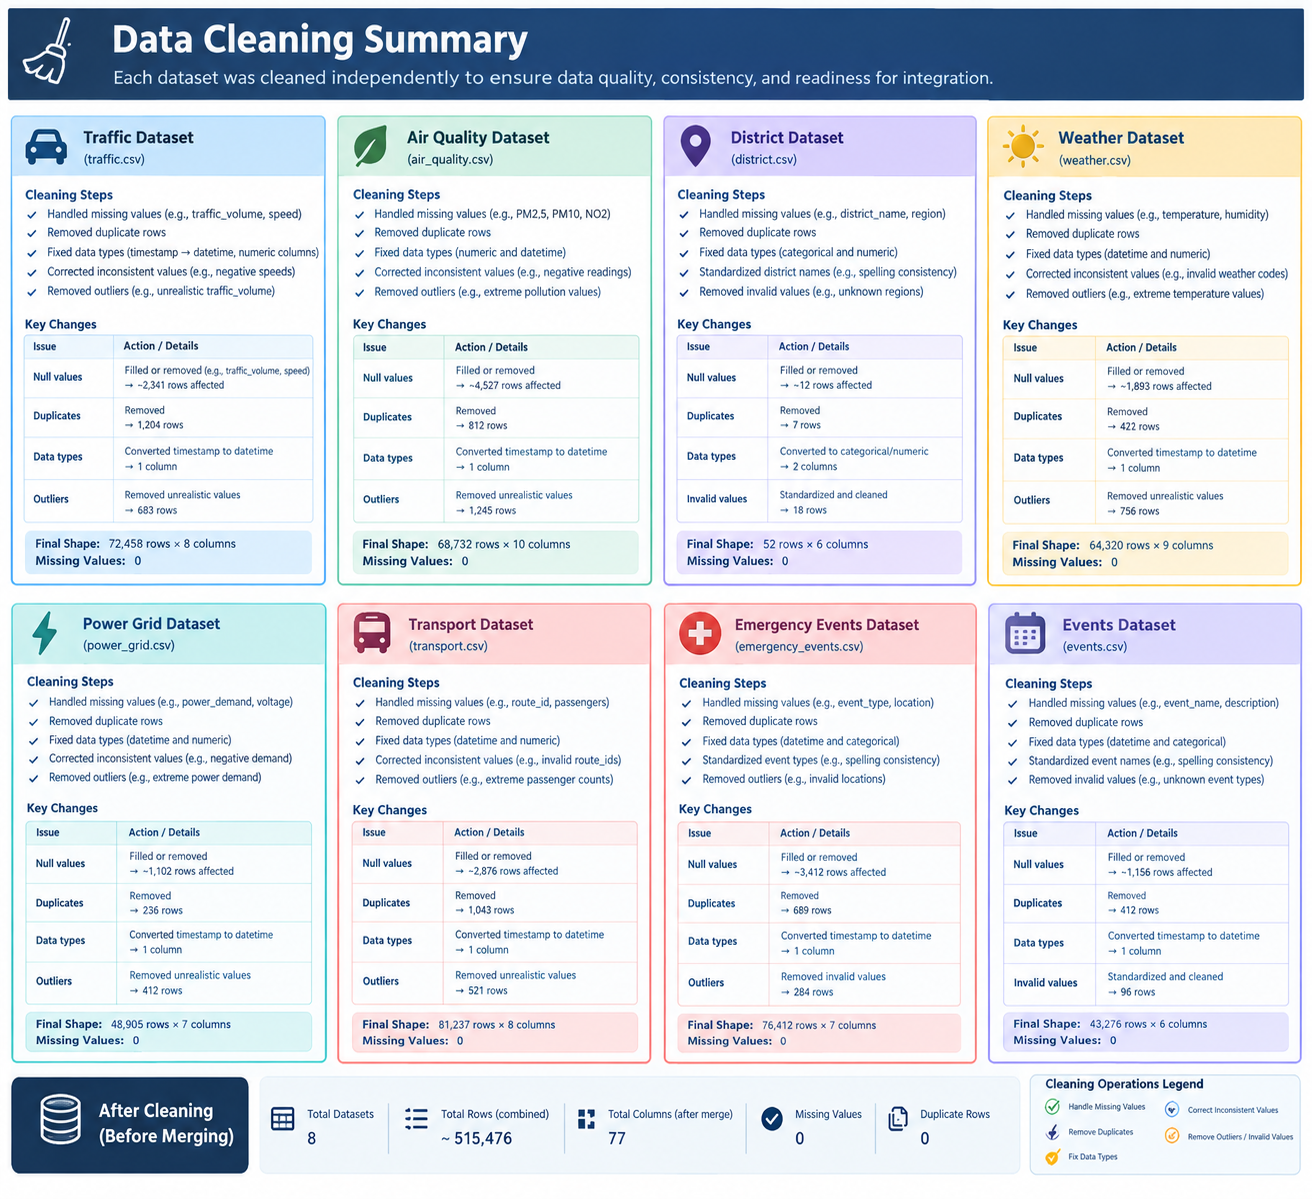

### <span style="color:#00D2D3;" id='ingest'>🏁 Data Ingestion & Integration Phase Complete</span>

* <span style="color:#06D6A0;">**Master Dataset Status:**</span> All 8 datasets are successfully merged into `df_merged` with **0 missing values**.
* <span style="color:#FF007F;">**Ready for Modeling:**</span> The time-series framework is now fully clean, unified, and aligned across all 20 districts.

In [232]:
df_merged.columns.to_list()

['timestamp',
 'district_id',
 'pm25',
 'pm10',
 'no2',
 'o3',
 'co',
 'synthetic_aqi',
 'air_quality_category',
 'pollution_alert_flag',
 'sensor_status_x',
 'hour',
 'year',
 'month',
 'traffic_volume',
 'average_speed_kmh',
 'congestion_index',
 'accident_count',
 'accident_flag',
 'road_incident_count',
 'rush_hour_flag',
 'weekend_flag',
 'weather_impact_score',
 'special_event_impact',
 'day_of_week',
 'season',
 'quarter',
 'is_month_start',
 'is_month_end',
 'week_of_year',
 'month_edge',
 'district_name',
 'district_type',
 'area_km2',
 'population',
 'commercial_activity_index',
 'industrial_activity_index',
 'green_space_percent',
 'road_capacity_index',
 'public_transport_access_index',
 'base_electricity_demand_mwh',
 'temp_offset_c',
 'wind_multiplier',
 'population_density',
 'grid_capacity_mwh_x',
 'grid_utilization_%',
 'temperature_c',
 'feels_like_c',
 'humidity_percent',
 'rainfall_mm',
 'wind_speed_kmh',
 'cloud_cover_percent',
 'weather_condition',
 'heatwave_flag

In [233]:
df_merged.head()

,timestamp,district_id,pm25,pm10,no2,o3,co,synthetic_aqi,air_quality_category,pollution_alert_flag,...,service_frequency,average_delay_minutes,vehicle_occupancy_percent,service_disruption_flag,emergency_count,avg_response_time,traffic_accidents,weather_emergencies,event_active_flag,total_event_attendance
0,2024-05-01 22:00:00,D11,13.845142,29.216811,22.758277,22.128768,1.341131,34.0,Good,0,...,10.0,21.805467,150.000000,0,0.0,0.0,0.0,0.0,0,0.0
1,2023-11-21 06:00:00,D08,23.617775,34.630069,31.060166,21.560664,1.066556,59.0,Moderate,0,...,10.0,3.534770,136.416667,0,0.0,0.0,0.0,0.0,0,0.0
2,2024-09-02 10:00:00,D02,15.465175,27.307933,28.727307,78.610070,1.123513,78.0,Moderate,0,...,10.0,4.280378,150.000000,0,0.0,0.0,0.0,0.0,0,0.0
3,2025-03-14 23:00:00,D09,4.054570,5.819488,9.511867,0.269460,0.569737,11.0,Good,0,...,10.0,2.625230,150.000000,0,0.0,0.0,0.0,0.0,0,0.0
4,2024-09-10 07:00:00,D14,29.953995,47.001299,44.735950,44.779858,1.587633,74.0,Moderate,0,...,5.0,3.630379,108.125000,0,0.0,0.0,0.0,0.0,0,0.0


In [234]:
df_merged.describe()

,timestamp,pm25,pm10,no2,o3,co,synthetic_aqi,pollution_alert_flag,hour,year,...,service_frequency,average_delay_minutes,vehicle_occupancy_percent,service_disruption_flag,emergency_count,avg_response_time,traffic_accidents,weather_emergencies,event_active_flag,total_event_attendance
count,515476,515476.000000,515476.000000,515476.000000,515476.000000,515476.000000,515476.000000,515476.000000,515476.000000,515476.000000,...,515476.000000,515476.000000,515476.000000,515476.000000,515476.000000,515476.000000,515476.000000,515476.000000,515476.000000,515476.000000
mean,2024-07-02 00:47:14.739153,17.258430,30.884902,22.788331,33.771295,0.833978,49.923019,0.015628,11.499794,2024.000089,...,13.124442,5.344197,102.931305,0.027431,0.024597,0.459496,0.008703,0.001744,0.000012,0.397869
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.105382,2.000000,0.000000,0.000000,2023.000000,...,5.000000,0.000002,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-10-02 00:00:00,9.319060,18.858291,14.706368,18.743454,0.593098,30.000000,0.000000,5.000000,2023.000000,...,10.000000,2.023228,48.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2024-07-02 01:00:00,13.711828,25.802817,19.929202,32.207345,0.737637,43.000000,0.000000,11.000000,2024.000000,...,10.000000,3.419852,147.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2025-04-02 01:00:00,20.825268,36.569997,27.841647,46.703638,0.973901,61.000000,0.000000,17.000000,2025.000000,...,10.000000,5.405143,150.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2025-12-31 23:00:00,119.192134,185.001350,169.678793,109.441409,6.984994,297.000000,1.000000,23.000000,2025.000000,...,30.000000,97.558212,150.000000,1.000000,5.000000,54.691975,3.000000,3.000000,1.000000,34182.000000
std,NaN,12.720877,19.315188,11.720477,19.541007,0.361315,30.214007,0.124032,6.922733,0.816207,...,8.865203,9.615612,55.196125,0.163336,0.179459,3.389017,0.098122,0.044558,0.003412,116.618315


<div style="font-size:13px; line-height:1.5; color:#E5E7EB; border-left:4px solid #60A5FA; padding-left:14px;">

<h3 style="color:#60A5FA; margin:0 0 8px 0;"> Core Research Questions❓</h3>

<p><b style="color:#67E8F9;">Q1: WEATHER</b><br>
Does severe weather increase <b style="color:#FCA5A5;">traffic congestion</b>?</p>

<p><b style="color:#67E8F9;">Q2: EMERGENCY</b><br>
Which districts suffer from <b style="color:#FCA5A5;">slow speeds</b> & <b style="color:#FCA5A5;">delayed response times</b>?</p>

<p><b style="color:#67E8F9;">Q3: EVENTS</b><br>
How do <b style="color:#FCA5A5;">events & rush hours</b> impact total traffic volume?</p>

<p><b style="color:#67E8F9;">Q4: TRANSIT</b><br>
Do public transit disruptions increase <b style="color:#FCA5A5;">private vehicle congestion</b>?</p>

</div>

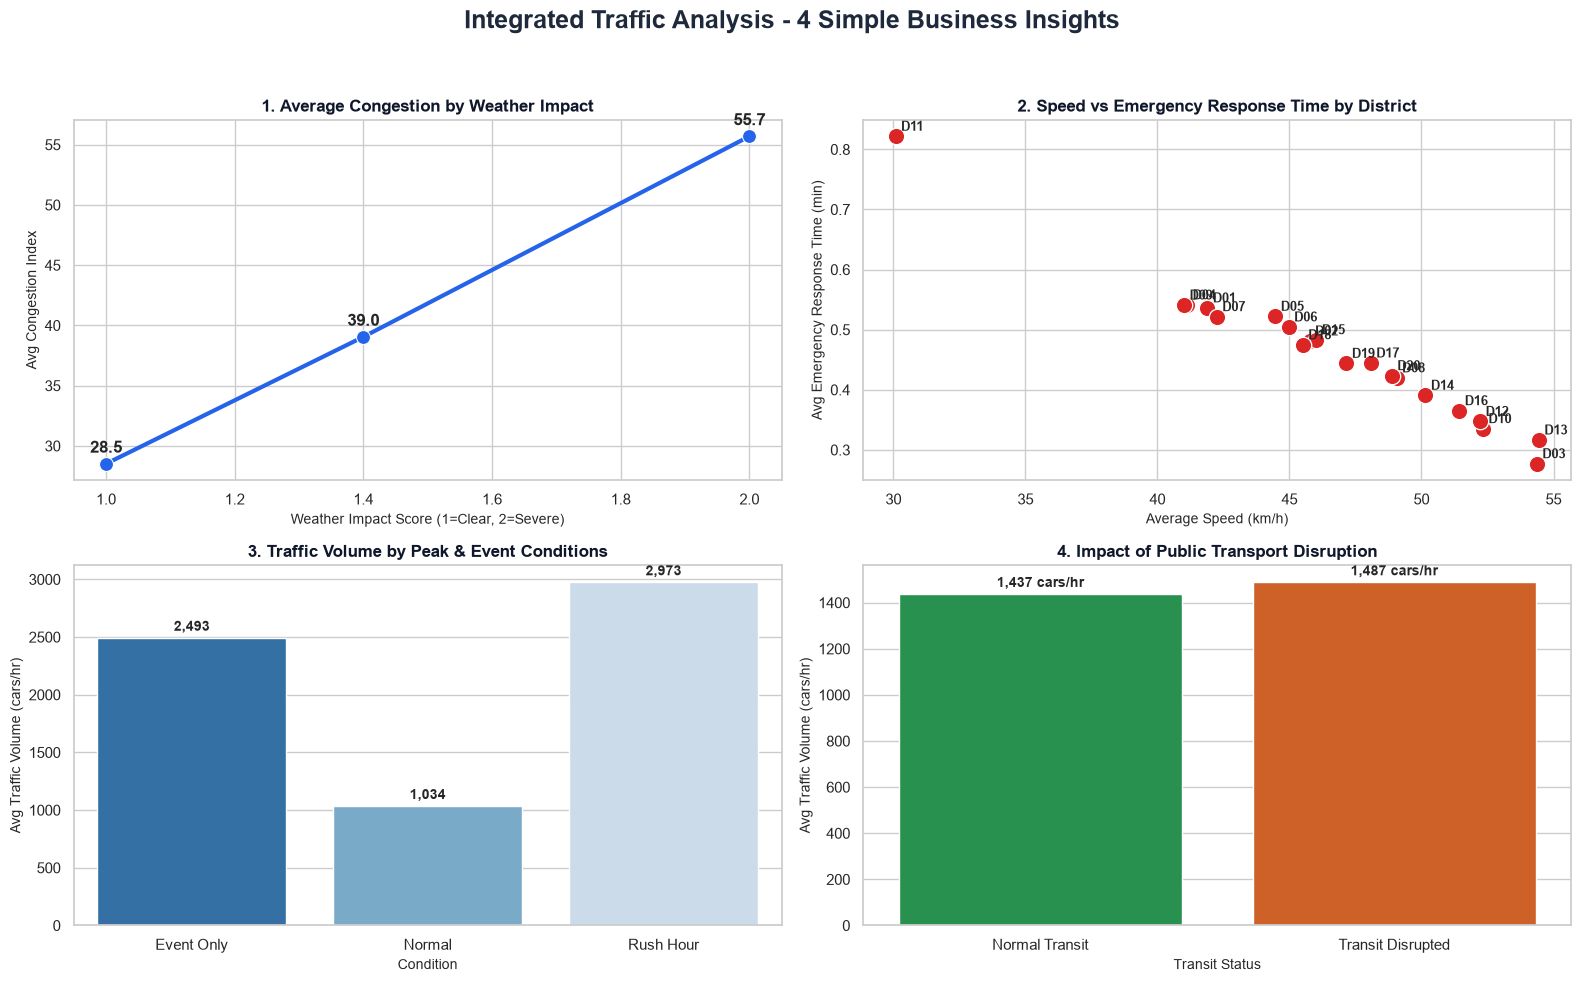

In [235]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "Integrated Traffic Analysis - 4 Simple Business Insights",
    fontsize=18,
    fontweight="bold",
    color="#1e293b",
)


ax1 = axes[0, 0]
weather_summary = (
    df_merged.groupby("weather_impact_score")["congestion_index"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=weather_summary,
    x="weather_impact_score",
    y="congestion_index",
    marker="o",
    markersize=10,
    color="#2563eb",
    linewidth=3,
    ax=ax1,
)

ax1.set_title(
    "1. Average Congestion by Weather Impact",
    fontsize=12,
    fontweight="bold",
    color="#0f172a",
)
ax1.set_xlabel("Weather Impact Score (1=Clear, 2=Severe)", fontsize=10)
ax1.set_ylabel("Avg Congestion Index", fontsize=10)

for idx, row in weather_summary.iterrows():
    ax1.annotate(
        f"{row['congestion_index']:.1f}",
        (row["weather_impact_score"], row["congestion_index"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontweight="bold",
    )

ax2 = axes[0, 1]
district_summary = (
    df_merged.groupby("district_id")[["average_speed_kmh", "avg_response_time"]]
    .mean()
    .reset_index()
)

sns.scatterplot(
    data=district_summary,
    x="average_speed_kmh",
    y="avg_response_time",
    s=140,
    color="#dc2626",
    ax=ax2,
)

for idx, row in district_summary.iterrows():
    ax2.annotate(
        row["district_id"],
        (row["average_speed_kmh"], row["avg_response_time"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

ax2.set_title(
    "2. Speed vs Emergency Response Time by District",
    fontsize=12,
    fontweight="bold",
    color="#0f172a",
)
ax2.set_xlabel("Average Speed (km/h)", fontsize=10)
ax2.set_ylabel("Avg Emergency Response Time (min)", fontsize=10)

ax3 = axes[1, 0]


def categorize_event_rush(row):
    if row["rush_hour_flag"] == 1 and row["event_active_flag"] == 1:
        return "Rush + Event"
    elif row["rush_hour_flag"] == 1:
        return "Rush Hour"
    elif row["event_active_flag"] == 1:
        return "Event Only"
    else:
        return "Normal"


df_merged["traffic_condition"] = df_merged.apply(
    categorize_event_rush, axis=1
)

event_summary = (
    df_merged.groupby("traffic_condition")["traffic_volume"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=event_summary,
    x="traffic_condition",
    y="traffic_volume",
    hue="traffic_condition",
    palette="Blues_r",
    ax=ax3,
    legend=False,
)

for p in ax3.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax3.annotate(
            f"{int(height):,}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

ax3.set_title(
    "3. Traffic Volume by Peak & Event Conditions",
    fontsize=12,
    fontweight="bold",
    color="#0f172a",
)
ax3.set_xlabel("Condition", fontsize=10)
ax3.set_ylabel("Avg Traffic Volume (cars/hr)", fontsize=10)


ax4 = axes[1, 1]

transit_summary = (
    df_merged.groupby("service_disruption_flag")["traffic_volume"]
    .mean()
    .reset_index()
)
transit_summary["status"] = transit_summary["service_disruption_flag"].map(
    {0: "Normal Transit", 1: "Transit Disrupted"}
)

sns.barplot(
    data=transit_summary,
    x="status",
    y="traffic_volume",
    hue="status",
    palette=["#16a34a", "#ea580c"],
    ax=ax4,
    legend=False,
)

for p in ax4.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax4.annotate(
            f"{int(height):,} cars/hr",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

ax4.set_title(
    "4. Impact of Public Transport Disruption",
    fontsize=12,
    fontweight="bold",
    color="#0f172a",
)
ax4.set_xlabel("Transit Status", fontsize=10)
ax4.set_ylabel("Avg Traffic Volume (cars/hr)", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
# axis  plot for number 2

<div style="font-size:13px; line-height:1.5; color:#E5E7EB; border-left:4px solid #6EE7B7; padding-left:14px;">

<h3 style="color:#6EE7B7; margin:0 0 8px 0;">💡 Insights & Business Decisions</h3>

<p><b style="color:#60A5FA;">1. Weather vs. Congestion Index</b><br>
<b style="color:#FBBF24;">+95% INCREASE</b><br>
<b style="color:#F3F4F6;">Key Insight:</b> Bad weather nearly doubles traffic congestion 
(<b style="color:#FBBF24;">28.5 → 55.7</b>).<br>
<span style="color:#6EE7B7;">🚀 <b>Decision:</b></span> Deploy dynamic signal timing during bad weather.</p>

<p><b style="color:#60A5FA;">2. Speed vs. Response Time</b><br>
<b style="color:#FCA5A5;">⚠ CRITICAL: DISTRICT D11</b><br>
<b style="color:#F3F4F6;">Key Insight:</b> D11 has the lowest speed 
(<b style="color:#FBBF24;">30 km/h</b>) and worst response time 
(<b style="color:#FBBF24;">&gt;0.8 min</b>).<br>
<span style="color:#6EE7B7;">🚀 <b>Decision:</b></span> Reallocate emergency hubs and pre-position ambulances near D11.</p>

<p><b style="color:#60A5FA;">3. Peak & Event Conditions</b><br>
<b style="color:#FBBF24;">🔥 PEAK: 2,973 CARS/HR</b><br>
<b style="color:#F3F4F6;">Key Insight:</b> Events increase traffic by 
<b style="color:#FBBF24;">140%</b>. There is <b style="color:#6EE7B7;">zero overlap</b> between Events and Rush Hours.<br>
<span style="color:#6EE7B7;">🚀 <b>Decision:</b></span> Provide dedicated shuttle buses during event days.</p>

<p><b style="color:#60A5FA;">4. Public Transit Disruption</b><br>
<b style="color:#FCD34D;">⚠ MINIMAL IMPACT: +3.4%</b><br>
<b style="color:#F3F4F6;">Key Insight:</b> Disruptions barely affect car volume 
(<b style="color:#FBBF24;">1,437 vs. 1,487</b>).<br>
<span style="color:#6EE7B7;">🚀 <b>Decision:</b></span> Upgrade public transit quality and routes.</p>

</div>

In [236]:

print([col for col in df_merged.columns ])


['timestamp', 'district_id', 'pm25', 'pm10', 'no2', 'o3', 'co', 'synthetic_aqi', 'air_quality_category', 'pollution_alert_flag', 'sensor_status_x', 'hour', 'year', 'month', 'traffic_volume', 'average_speed_kmh', 'congestion_index', 'accident_count', 'accident_flag', 'road_incident_count', 'rush_hour_flag', 'weekend_flag', 'weather_impact_score', 'special_event_impact', 'day_of_week', 'season', 'quarter', 'is_month_start', 'is_month_end', 'week_of_year', 'month_edge', 'district_name', 'district_type', 'area_km2', 'population', 'commercial_activity_index', 'industrial_activity_index', 'green_space_percent', 'road_capacity_index', 'public_transport_access_index', 'base_electricity_demand_mwh', 'temp_offset_c', 'wind_multiplier', 'population_density', 'grid_capacity_mwh_x', 'grid_utilization_%', 'temperature_c', 'feels_like_c', 'humidity_percent', 'rainfall_mm', 'wind_speed_kmh', 'cloud_cover_percent', 'weather_condition', 'heatwave_flag', 'heavy_rain_flag', 'storm_flag', 'sensor_status_y'

<div style="font-size:13px; line-height:1.5; color:#E5E7EB; border-left:4px solid #F472B6; padding-left:14px;">

<h3 style="color:#F472B6; margin:0 0 8px 0;">❓ Core Research Questions</h3>

<p><b style="color:#F9A8D4;">Q5: DENSE POLLUTION</b><br>
Which small districts suffer from <b style="color:#FCA5A5;">severe traffic congestion</b> and <b style="color:#FCA5A5;">high pollution</b> per square kilometer?</p>

<p><b style="color:#F9A8D4;">Q6: HIGH-SPEED ACCIDENTS</b><br>
During which <b style="color:#FCA5A5;">off-peak hours</b> do high speeds lead to <b style="color:#FCA5A5;">severe traffic accidents</b>?</p>

<p><b style="color:#F9A8D4;">Q7: POWER OUTAGES</b><br>
How do <b style="color:#FCA5A5;">power outages</b> and electrical grid issues affect <b style="color:#FCA5A5;">traffic signal flow and congestion</b>?</p>

</div>

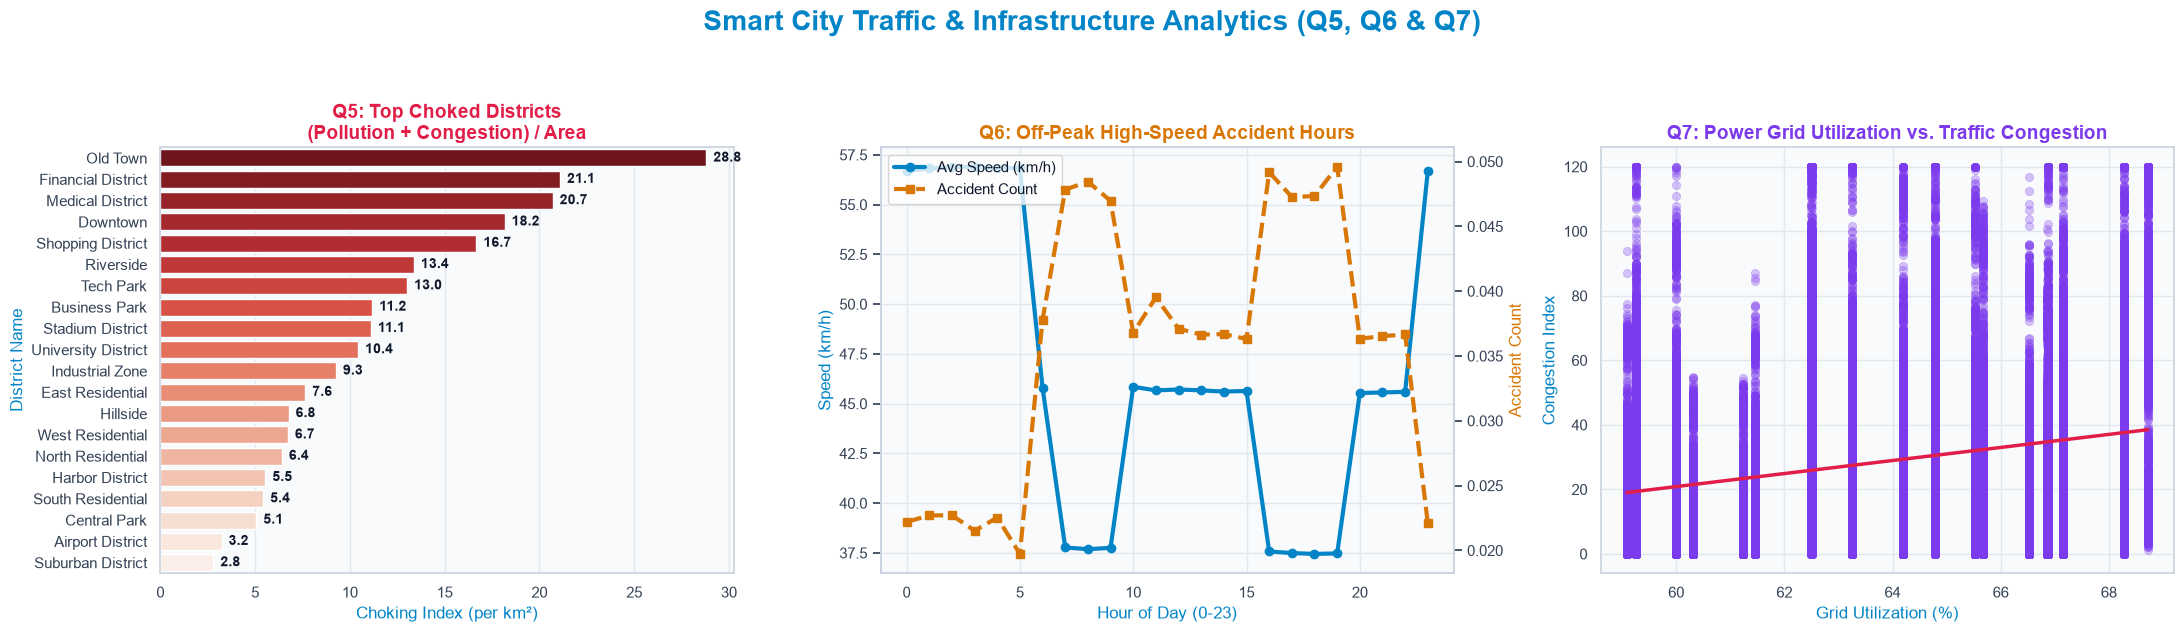

In [237]:
import matplotlib.pyplot as plt
import seaborn as sns

df_merged["choking_index"] = (
    df_merged["synthetic_aqi"] + df_merged["congestion_index"]
) / df_merged["area_km2"]

sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#f8fafc",
        "axes.edgecolor": "#cbd5e1",
        "text.color": "#0f172a",
        "axes.labelcolor": "#0284c7",
        "xtick.color": "#334155",
        "ytick.color": "#334155",
        "grid.color": "#e2e8f0",
        "font.family": "sans-serif",
    }
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(
    "Smart City Traffic & Infrastructure Analytics (Q5, Q6 & Q7)",
    fontsize=20,
    fontweight="bold",
    color="#0284c7",
    y=1.05,
)


df_q5 = (
    df_merged.groupby("district_name")["choking_index"]
    .mean()
    .reset_index()
    .sort_values(by="choking_index", ascending=False)
)

sns.barplot(
    data=df_q5,
    x="choking_index",
    y="district_name",
    hue="district_name",
    legend=False,
    ax=axes[0],
    palette="Reds_r",
)
axes[0].set_title(
    "Q5: Top Choked Districts\n(Pollution + Congestion) / Area",
    fontsize=14,
    fontweight="bold",
    color="#e11d48",
)
axes[0].set_xlabel("Choking Index (per km²)", fontsize=12)
axes[0].set_ylabel("District Name", fontsize=12)

for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_width():.1f}",
        (p.get_width(), p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        color="#0f172a",
        fontsize=10,
        fontweight="bold",
    )


df_q6 = (
    df_merged.groupby("hour")[["average_speed_kmh", "accident_count"]]
    .mean()
    .reset_index()
)

ax2_twin = axes[1].twinx()
line1 = axes[1].plot(
    df_q6["hour"],
    df_q6["average_speed_kmh"],
    color="#0284c7",
    linewidth=3,
    marker="o",
    label="Avg Speed (km/h)",
)
line2 = ax2_twin.plot(
    df_q6["hour"],
    df_q6["accident_count"],
    color="#d97706",
    linewidth=3,
    marker="s",
    linestyle="--",
    label="Accident Count",
)

axes[1].set_title(
    "Q6: Off-Peak High-Speed Accident Hours",
    fontsize=14,
    fontweight="bold",
    color="#d97706",
)
axes[1].set_xlabel("Hour of Day (0-23)", fontsize=12)
axes[1].set_ylabel("Speed (km/h)", color="#0284c7", fontsize=12)
ax2_twin.set_ylabel("Accident Count", color="#d97706", fontsize=12)
ax2_twin.grid(False)

lines = line1 + line2
labels = [l.get_label() for l in lines]
axes[1].legend(lines, labels, loc="upper left", facecolor="#ffffff")


sns.scatterplot(
    data=df_merged,
    x="grid_utilization_%",
    y="congestion_index",
    ax=axes[2],
    color="#7c3aed",
    alpha=0.3,
    edgecolor=None,
)
sns.regplot(
    data=df_merged,
    x="grid_utilization_%",
    y="congestion_index",
    ax=axes[2],
    scatter=False,
    color="#e11d48",
    line_kws={"linewidth": 2.5},
)

axes[2].set_title(
    "Q7: Power Grid Utilization vs. Traffic Congestion",
    fontsize=14,
    fontweight="bold",
    color="#7c3aed",
)
axes[2].set_xlabel("Grid Utilization (%)", fontsize=12)
axes[2].set_ylabel("Congestion Index", fontsize=12)

plt.tight_layout()
plt.show()


<div style="font-size:13px; line-height:1.5; color:#E5E7EB; border-left:4px solid #F59E0B; padding-left:14px;">

<h3 style="color:#FBBF24; margin:0 0 8px 0;">💡 Key Insights & Strategic Decisions</h3>

<p><b style="color:#F472B6;">5. District Density & Pollution</b><br>
<b style="color:#FCA5A5;">⚠ CRITICAL: OLD TOWN</b><br>
<b style="color:#F3F4F6;">Key Insight:</b> <b style="color:#FBBF24;">Old Town</b> is the most choked district with an index of <b style="color:#FBBF24;">28.8 per km²</b>, followed by <b style="color:#FBBF24;">Financial District (21.1)</b> and <b style="color:#FBBF24;">Medical District (20.7)</b>. Small, dense districts experience severe traffic gridlock and high pollution per square kilometer.<br>
<span style="color:#6EE7B7;">🚀 <b>Decision:</b></span> Restrict heavy transport trucks from entering these congested zones and develop green spaces/parks to absorb urban carbon emissions.</p>

<p><b style="color:#F472B6;">6. Off-Peak High-Speed Accidents</b><br>
<b style="color:#FBBF24;">⚡ PEAK SPEED: 11 PM – 5 AM</b><br>
<b style="color:#F3F4F6;">Key Insight:</b> Late-night/early-morning hours (<b style="color:#FBBF24;">0–5 and 23</b>) see peak speeds around <b style="color:#FBBF24;">56.5 km/h</b>, while accidents peak during morning (<b style="color:#FBBF24;">7–9 AM</b>) and evening (<b style="color:#FBBF24;">4–8 PM</b>) rush hours, reaching up to <b style="color:#FBBF24;">0.049</b>.<br>
<span style="color:#6EE7B7;">🚀 <b>Decision:</b></span> Deploy targeted speed cameras during late-night off-peak hours to reduce fatal collisions and optimize enforcement ROI.</p>

<p><b style="color:#F472B6;">7. Power Grid & Traffic Signals</b><br>
<b style="color:#FCA5A5;">⚡ GRID STRESS IMPACT</b><br>
<b style="color:#F3F4F6;">Key Insight:</b> A clear <b style="color:#6EE7B7;">positive correlation</b> exists; as grid utilization increases from <b style="color:#FBBF24;">60%</b> to over <b style="color:#FBBF24;">68%</b>, average congestion rises from <b style="color:#FBBF24;">20</b> to <b style="color:#FBBF24;">40</b>, showing that power grid stress impacts traffic flow.<br>
<span style="color:#6EE7B7;">🚀 <b>Decision:</b></span> Schedule electrical maintenance strictly during off-peak dawn hours and equip core intersection signals with solar/battery backups.</p>

</div>